In [331]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
)

### Loading Dataset

In [332]:
wine_data = pd.read_csv('wine_quality.csv')

### Check how the data is distributed

In [333]:
wine_data.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [334]:
wine_data.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


### Information about the data columns

In [335]:
wine_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [336]:
wine_data['quality'].value_counts().sort_index()

quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64

### How the data columns are distributed?

### Distribution of quality labels

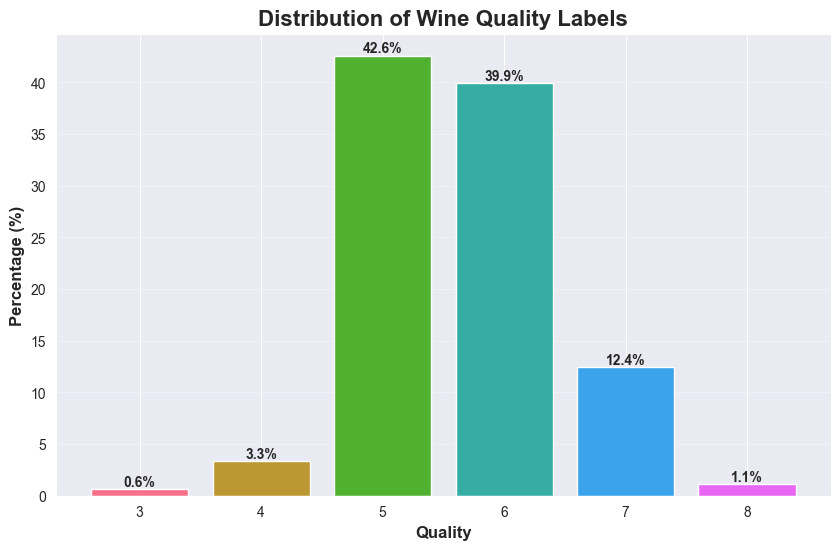

In [337]:
quality_counts = wine_data['quality'].value_counts().sort_index()

quality_percentages = (quality_counts / quality_counts.sum()) * 100

# Create a bar chart
plt.figure(figsize=(10, 6))
bars = plt.bar(quality_percentages.index, quality_percentages.values, 
               color=sns.color_palette('husl', len(quality_percentages)))

# Add percentage labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.1f}%',
             ha='center', va='bottom', fontweight='bold')

plt.xlabel('Quality', fontsize=12, fontweight='bold')
plt.ylabel('Percentage (%)', fontsize=12, fontweight='bold')
plt.title('Distribution of Wine Quality Labels', fontsize=16, fontweight='bold')
plt.xticks(quality_percentages.index)
plt.grid(axis='y', alpha=0.3)
plt.show()

<Axes: xlabel='quality', ylabel='fixed acidity'>

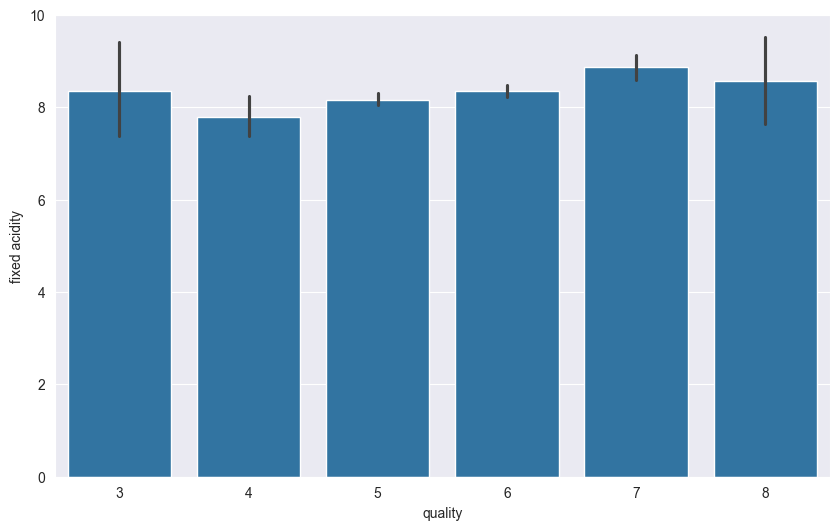

In [338]:
fig = plt.figure(figsize = (10,6))
sns.barplot(x = 'quality', y = 'fixed acidity', data = wine_data)


`Fixed acity does not give any specification to classify the quality`

<Axes: xlabel='quality', ylabel='volatile acidity'>

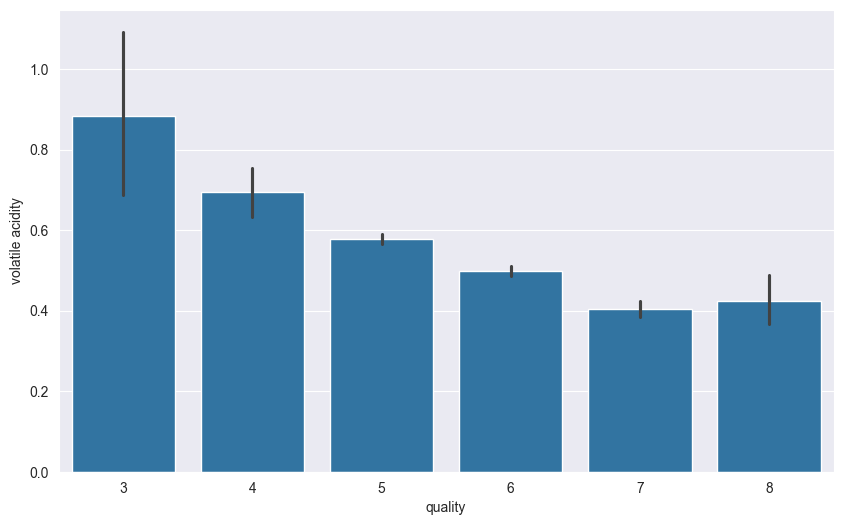

In [339]:
fig = plt.figure(figsize = (10,6))
sns.barplot(x = 'quality', y = 'volatile acidity', data = wine_data)


`Quite a downing trend in the volatile acidy as we go higher the quality`

<Axes: xlabel='quality', ylabel='citric acid'>

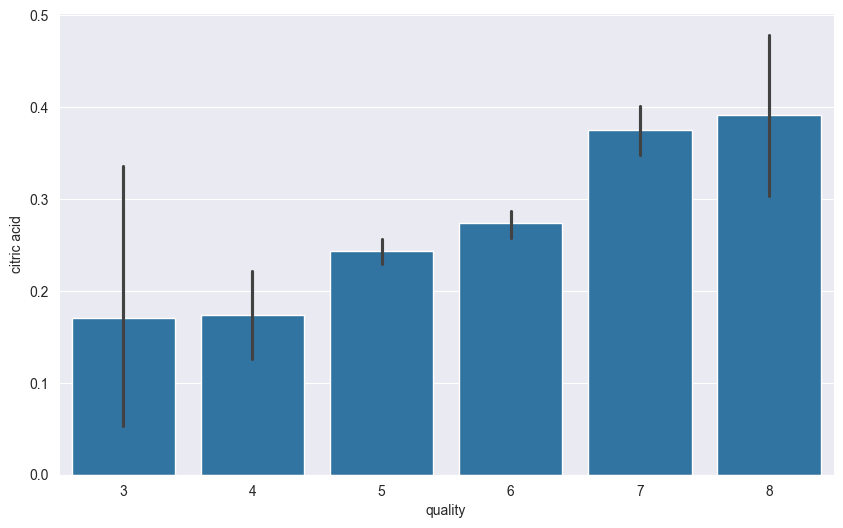

In [340]:
fig = plt.figure(figsize = (10,6))
sns.barplot(x = 'quality', y = 'citric acid', data = wine_data)


`Citric acid go higher as we go higher in the quality of the wine`

<Axes: xlabel='quality', ylabel='residual sugar'>

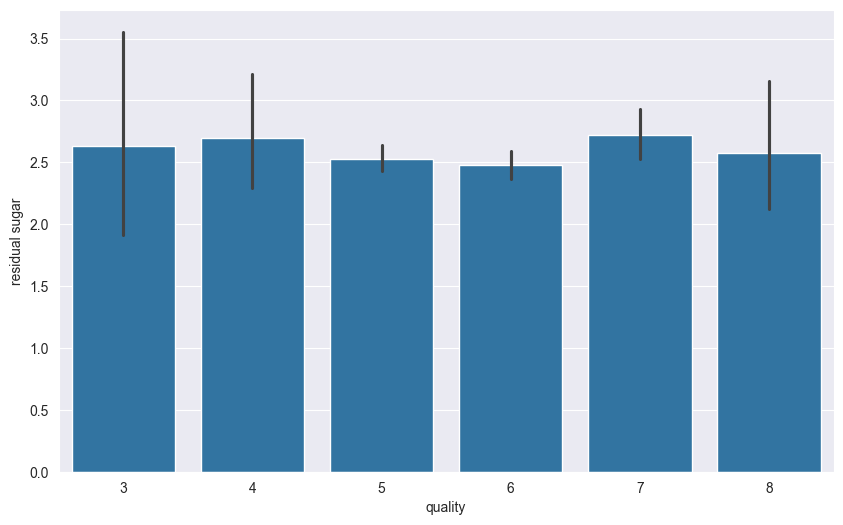

In [341]:
fig = plt.figure(figsize = (10,6))
sns.barplot(x = 'quality', y = 'residual sugar', data = wine_data)


`Residual sugar does not give any specification to classify the quality`

<Axes: xlabel='quality', ylabel='chlorides'>

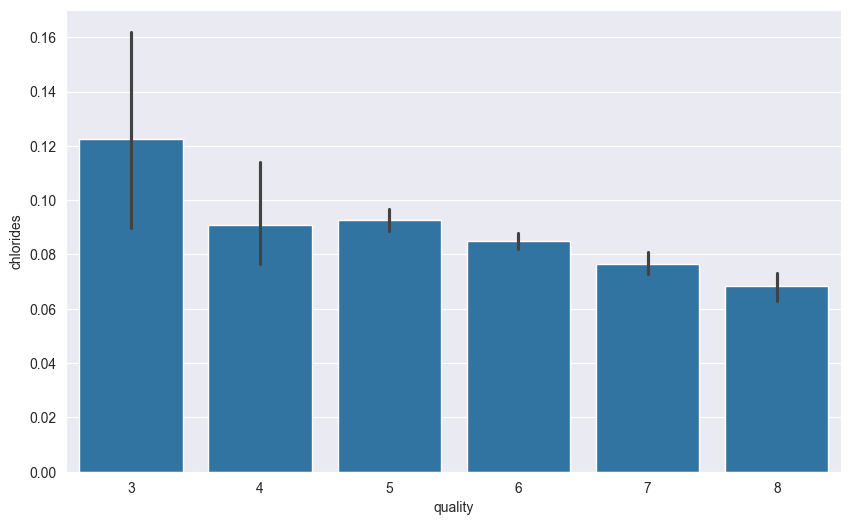

In [342]:
fig = plt.figure(figsize = (10,6))
sns.barplot(x = 'quality', y = 'chlorides', data = wine_data)


`Composition of chloride also go down as we go higher in the quality of the wine`

<Axes: xlabel='quality', ylabel='free sulfur dioxide'>

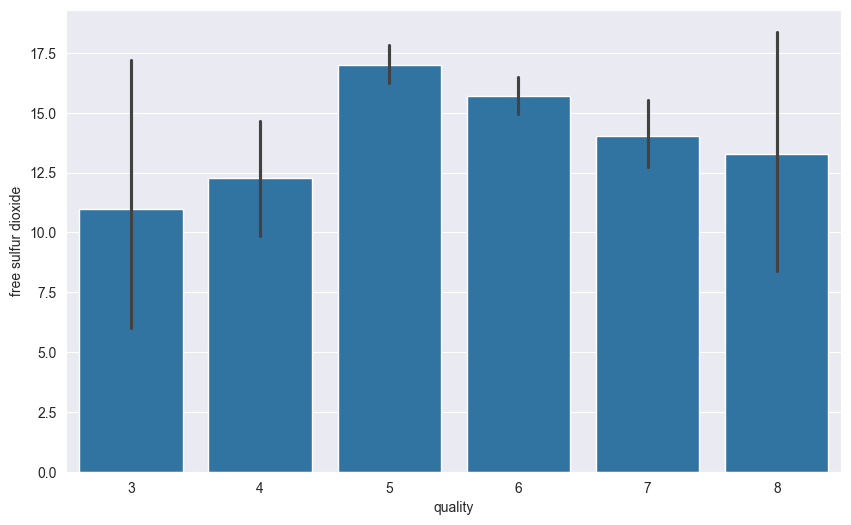

In [343]:
fig = plt.figure(figsize = (10,6))
sns.barplot(x = 'quality', y = 'free sulfur dioxide', data = wine_data)


<Axes: xlabel='quality', ylabel='total sulfur dioxide'>

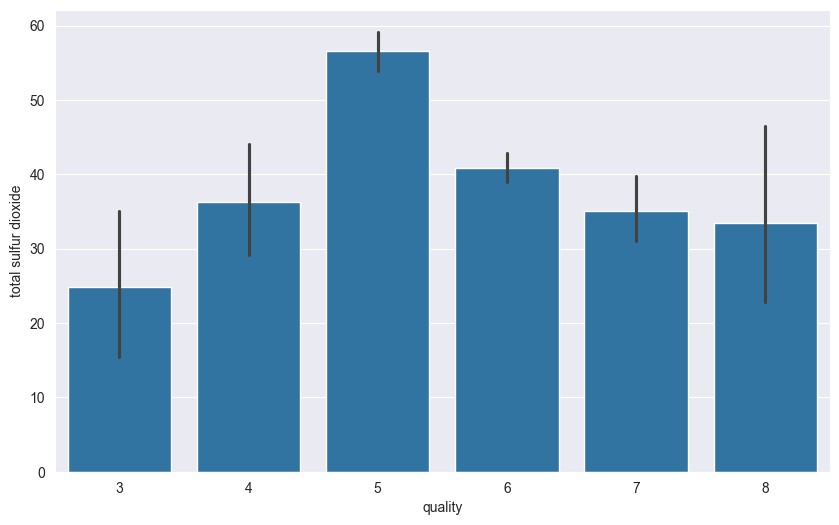

In [344]:
fig = plt.figure(figsize = (10,6))
sns.barplot(x = 'quality', y = 'total sulfur dioxide', data = wine_data)


<Axes: xlabel='quality', ylabel='density'>

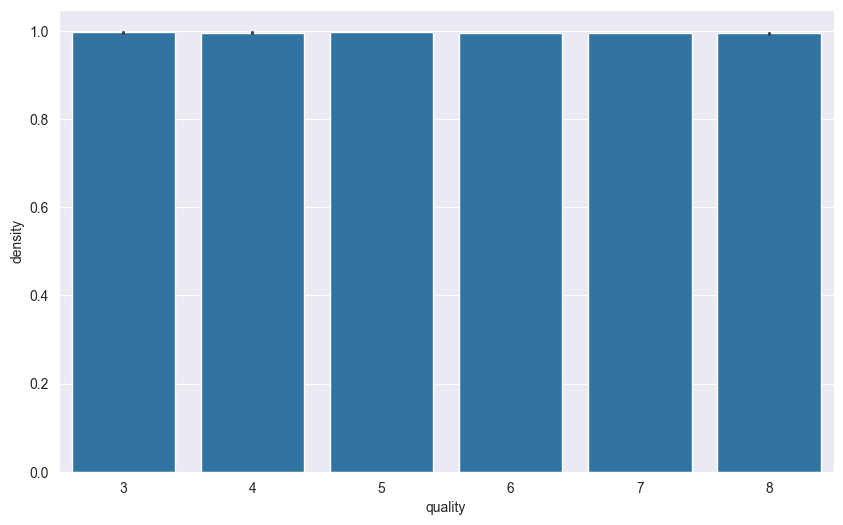

In [345]:
fig = plt.figure(figsize = (10,6))
sns.barplot(x = 'quality', y = 'density', data = wine_data)


<Axes: xlabel='quality', ylabel='pH'>

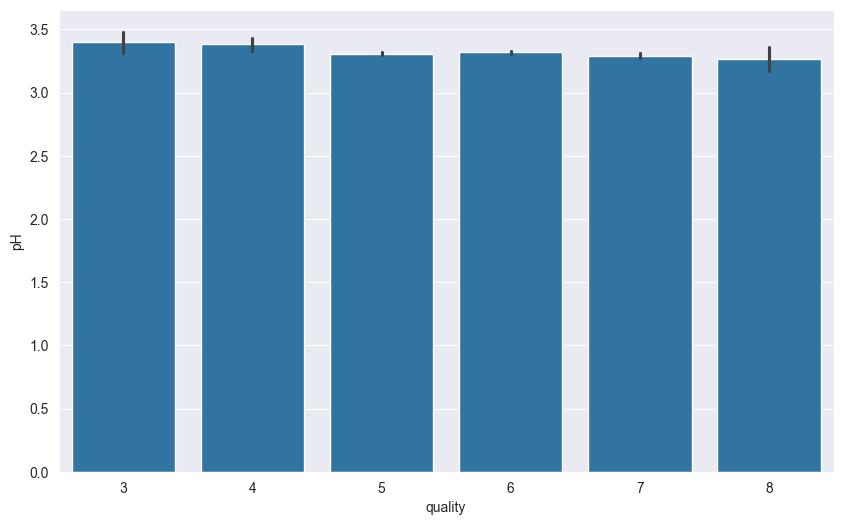

In [346]:
fig = plt.figure(figsize = (10,6))
sns.barplot(x = 'quality', y = 'pH', data = wine_data)


<Axes: xlabel='quality', ylabel='sulphates'>

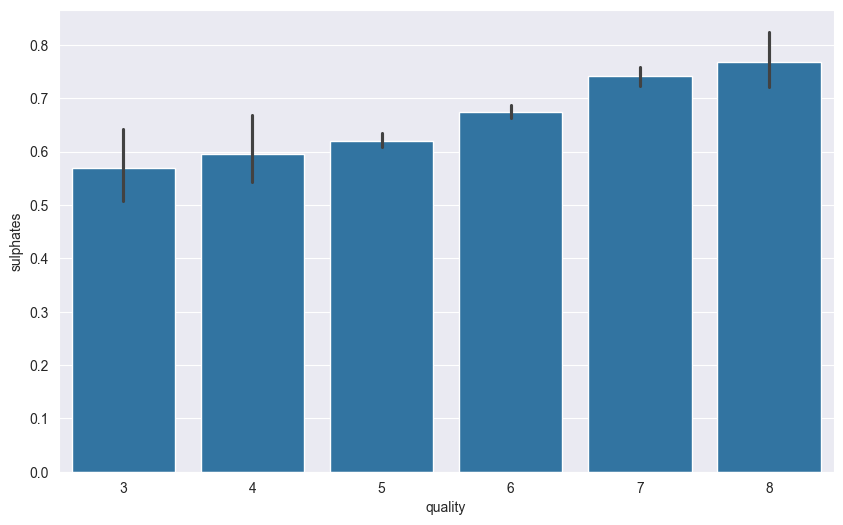

In [347]:
fig = plt.figure(figsize = (10,6))
sns.barplot(x = 'quality', y = 'sulphates', data = wine_data)


`Sulphates level goes higher with the quality of wine`

<Axes: xlabel='quality', ylabel='alcohol'>

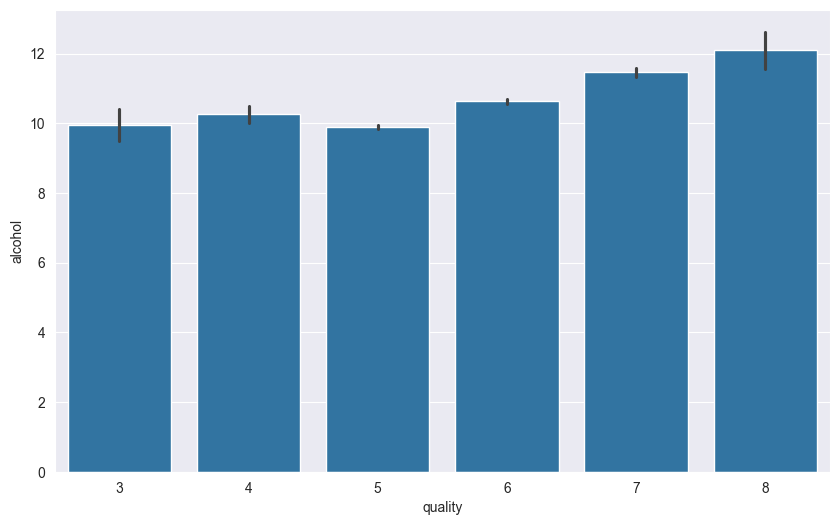

In [348]:
fig = plt.figure(figsize = (10,6))
sns.barplot(x = 'quality', y = 'alcohol', data = wine_data)


`Alcohol level also goes higher as te quality of wine increases`

## Missing values e linhas duplicadas

In [349]:
print("Missing values por coluna:\n")
print(wine_data.isna().sum())

print("\nTotal de missing values no dataset:", wine_data.isna().sum().sum())

print("\nTotal de linhas duplicadas:")
print(wine_data.duplicated().sum())

#apagar duplicados
wine_data = wine_data.drop_duplicates()


Missing values por coluna:

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

Total de missing values no dataset: 0

Total de linhas duplicadas:
240


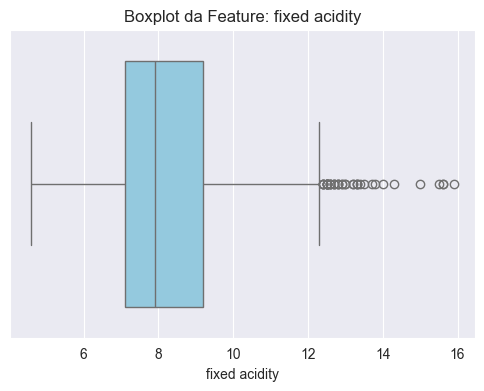

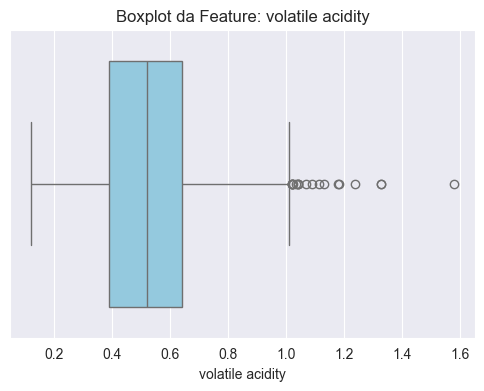

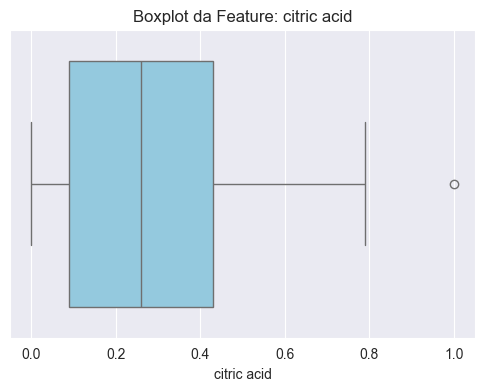

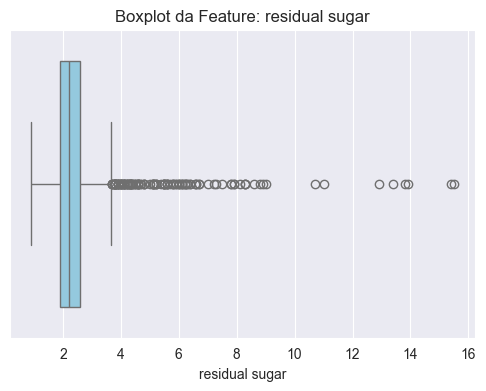

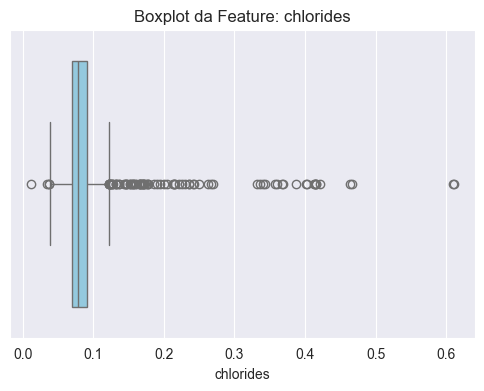

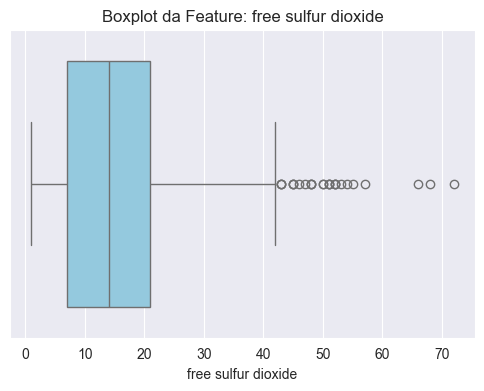

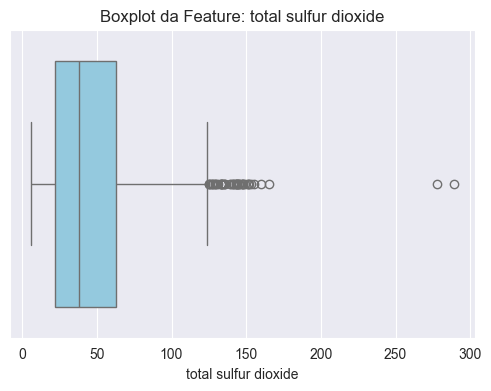

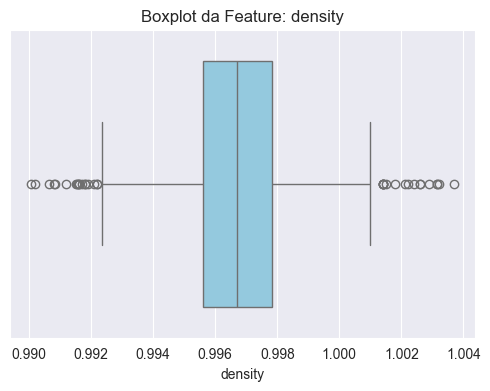

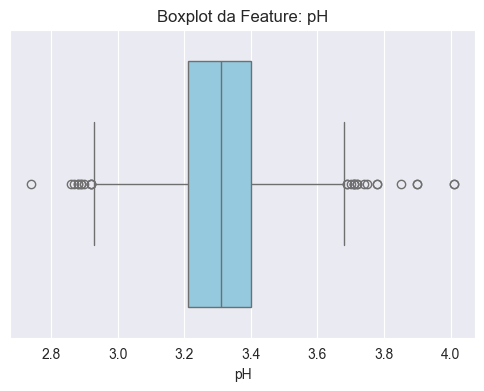

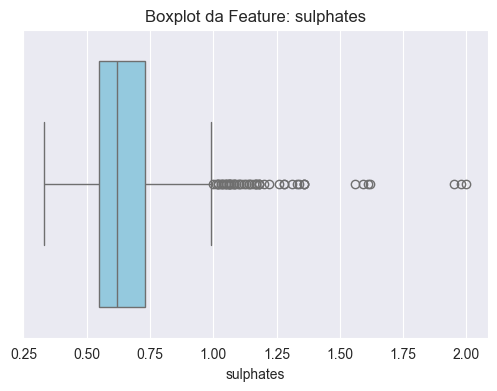

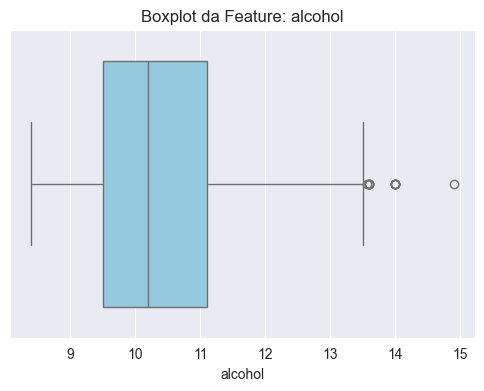

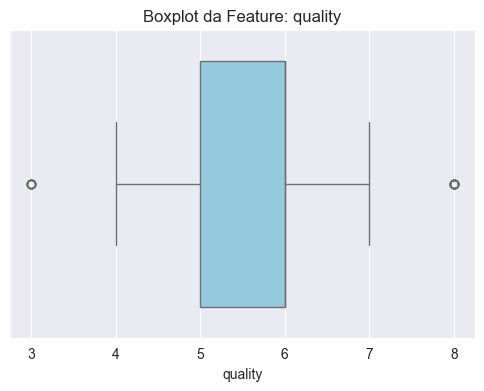

In [350]:
import matplotlib.pyplot as plt
import seaborn as sns

for col in wine_data.columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=wine_data[col], color='skyblue')
    plt.title(f"Boxplot da Feature: {col}")
    plt.xlabel(col)
    plt.show()



In [351]:
import pandas as pd
import numpy as np

outlier_summary = []

for col in wine_data.columns:
    if wine_data[col].dtype != 'object':  # só colunas numéricas

        Q1 = wine_data[col].quantile(0.25)
        Q3 = wine_data[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # mascara para outliers
        outliers = wine_data[(wine_data[col] < lower_bound) | (wine_data[col] > upper_bound)]
        num_outliers = outliers.shape[0]
        total = wine_data.shape[0]
        perc_outliers = (num_outliers / total) * 100

        outlier_summary.append([col, num_outliers, total, perc_outliers])

# Criar DataFrame final
outlier_df = pd.DataFrame(outlier_summary,
                          columns=["Feature", "Nº Outliers", "Total", "Percentagem (%)"])

# Ordenar da variável com mais outliers para a com menos
outlier_df = outlier_df.sort_values(by="Percentagem (%)", ascending=False)

outlier_df


,Feature,Nº Outliers,Total,Percentagem (%)
3,residual sugar,126,1359,9.271523
4,chlorides,87,1359,6.401766
9,sulphates,55,1359,4.047093
6,total sulfur dioxide,45,1359,3.311258
0,fixed acidity,41,1359,3.016924
7,density,35,1359,2.575423
8,pH,28,1359,2.060338
11,quality,27,1359,1.986755
5,free sulfur dioxide,26,1359,1.913171
1,volatile acidity,19,1359,1.398087


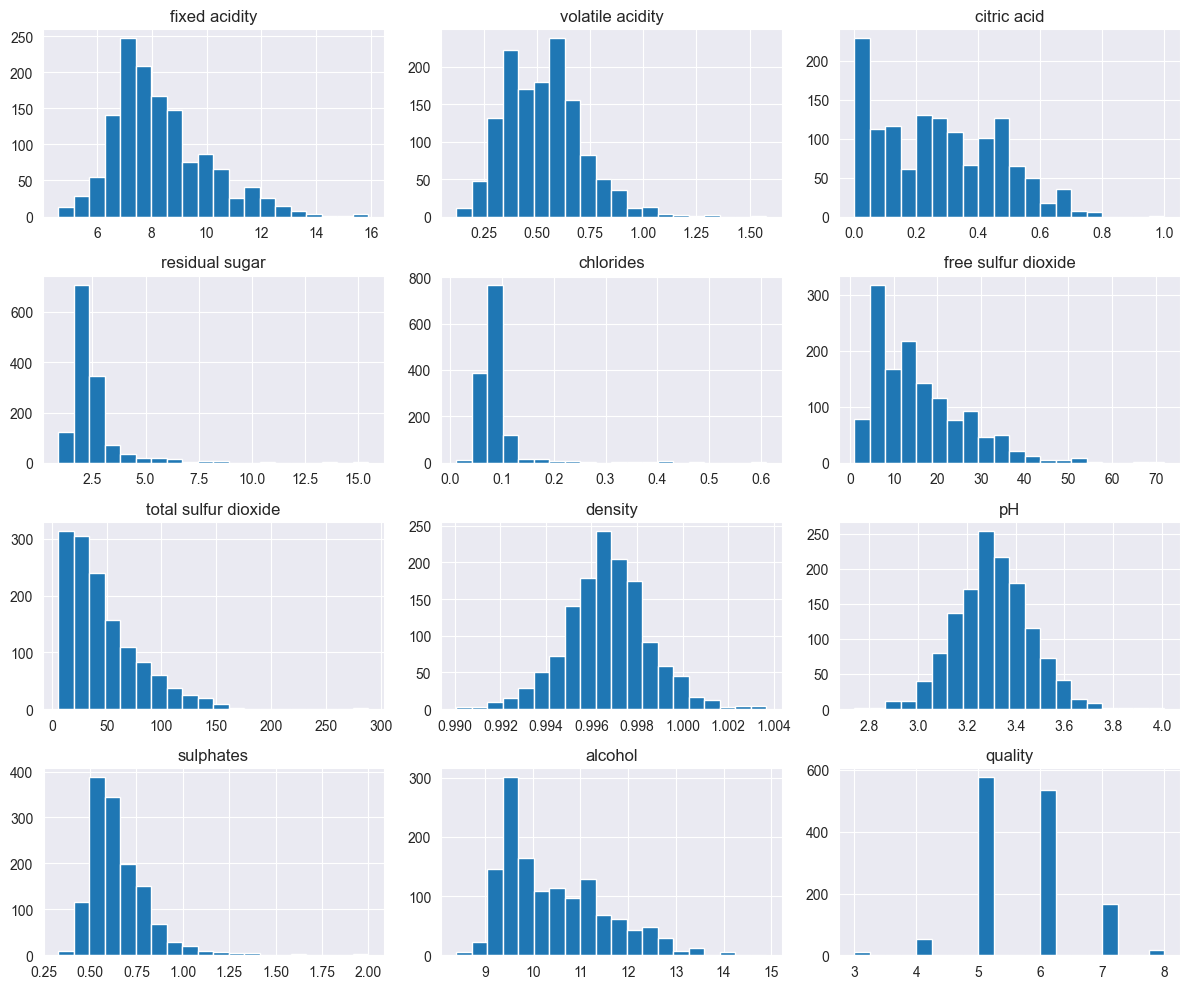

In [352]:
wine_data.hist(figsize=(12,10), bins=20)
plt.tight_layout()
plt.show()


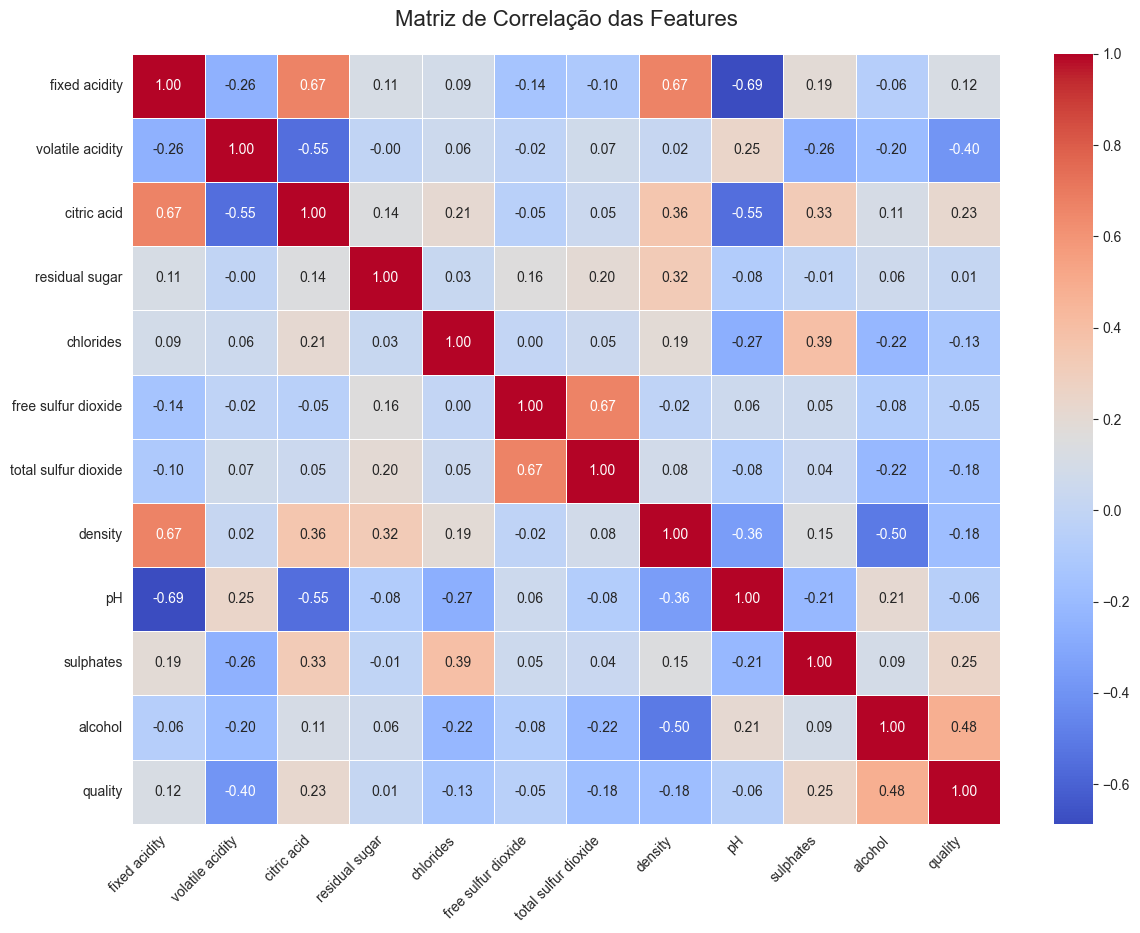

In [353]:
plt.figure(figsize=(14,10))

sns.heatmap(
    wine_data.corr(),
    annot=True,            # mostra valores
    fmt=".2f",             # 2 casas decimais
    cmap="coolwarm",       # mapa de cores perceptível
    linewidths=0.5,        # linhas entre células
    annot_kws={"size": 10} # tamanho do texto
)

plt.title("Matriz de Correlação das Features", fontsize=16, pad=20)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.show()



In [354]:
wine_data.corr()['quality'].sort_values(ascending=False)


quality                 1.000000
alcohol                 0.480343
sulphates               0.248835
citric acid             0.228057
fixed acidity           0.119024
residual sugar          0.013640
free sulfur dioxide    -0.050463
pH                     -0.055245
chlorides              -0.130988
total sulfur dioxide   -0.177855
density                -0.184252
volatile acidity       -0.395214
Name: quality, dtype: float64

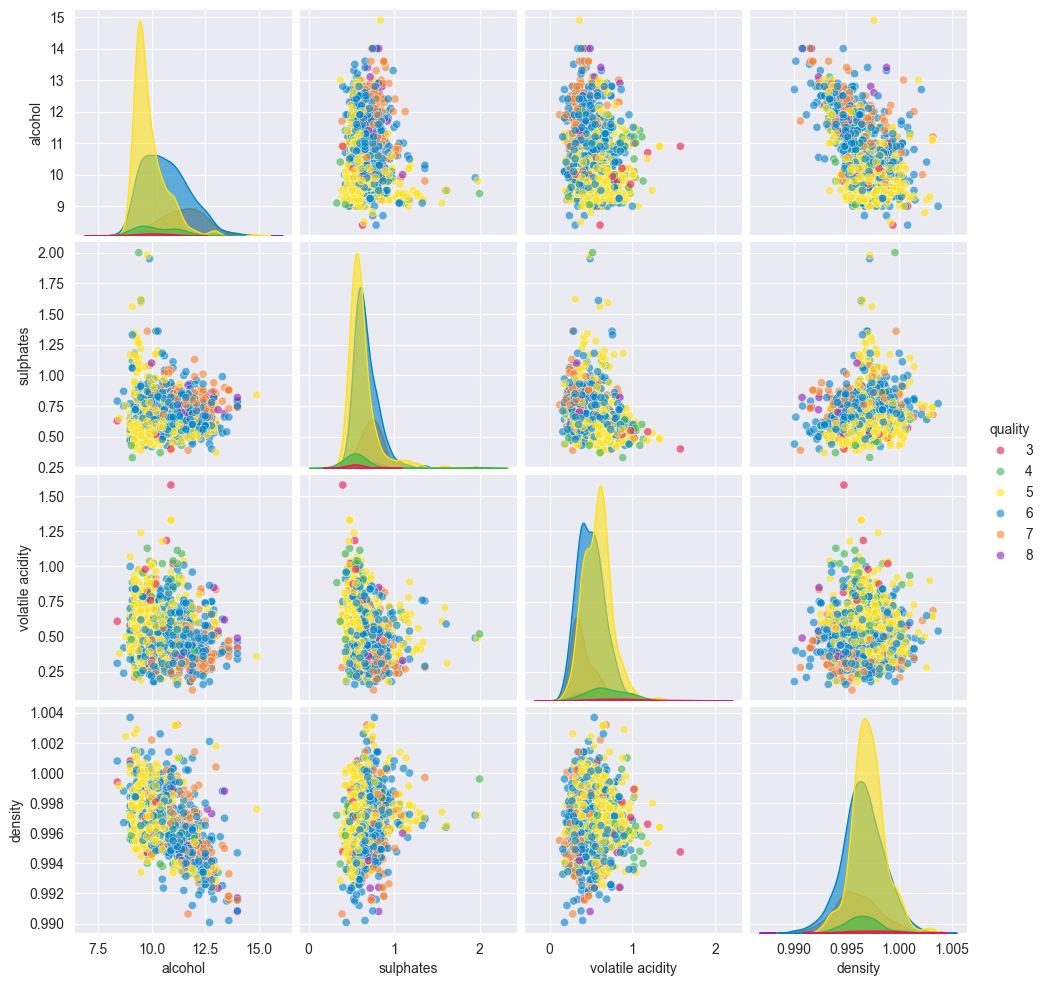

In [355]:
top_corr = ['alcohol', 'sulphates', 'volatile acidity', 'density', 'quality']
custom_palette = {
    3: '#e6194b',  # red
    4: '#3cb44b',  # green
    5: '#ffe119',  # yellow
    6: '#0082c8',  # blue
    7: '#f58231',  # orange
    8: '#911eb4'   # purple
}

sns.pairplot(
    wine_data[top_corr],
    hue='quality',
    palette=custom_palette,
    plot_kws={'alpha':0.6, 's':35},
    diag_kws={'alpha':0.6}
)





## process data

In [356]:
wine_data_bi=wine_data.copy()

# 1. Criar a classificação binária baseada na regra:
# quality <= 5 -> 'under-average'
# quality >= 6 -> 'above-average'
wine_data_bi['Target'] = wine_data_bi['quality'].apply(lambda x: 1 if x >= 6 else 0)

wine_data_bi=wine_data_bi.drop(columns=['quality'])

wine_data_bi.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,Target
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,1
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,0


## Correlação da variavel binaria Target

In [357]:
wine_data_bi.corr()['Target'].sort_values(ascending=False)


Target                  1.000000
alcohol                 0.446176
sulphates               0.211365
citric acid             0.167903
fixed acidity           0.091761
pH                      0.004693
residual sugar         -0.002371
free sulfur dioxide    -0.069207
chlorides              -0.115071
density                -0.168958
total sulfur dioxide   -0.235046
volatile acidity       -0.327195
Name: Target, dtype: float64

In [358]:
wine_data_bi["Target"].value_counts()


Target
1    719
0    640
Name: count, dtype: int64

## Classificaçao binaria


## Com todas as features

Separar X e y

In [359]:
X = wine_data_bi.drop(columns=['Target'])
y = wine_data_bi['Target']


Train/Test Split (75/25 + stratify + random_state=42)


In [360]:


X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)


Normalização (StandardScaler)

In [361]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

## NEURAL NETWORK – Modelo Base (MLPClassifier)

#### Função de diagnóstico de overfitting/underfitting

In [362]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score

def diagnosticar_neural_network(modelo, X_train, X_test, y_train, y_test, nome_modelo="Neural Network"):
    """
    Diagnóstica overfitting/underfitting numa Neural Network
    
    Parâmetros:
    -----------
    modelo : MLPClassifier já treinado
    X_train, X_test : dados de treino e teste (normalizados)
    y_train, y_test : labels de treino e teste
    nome_modelo : str, nome para identificar no output
    
    Retorna:
    --------
    dict com métricas de diagnóstico
    """
    
    # ========================================
    # 1. CALCULAR ACCURACIES
    # ========================================
    train_acc = modelo.score(X_train, y_train)
    test_acc = modelo.score(X_test, y_test)
    gap = train_acc - test_acc
    
    # ========================================
    # 2. IMPRIMIR RELATÓRIO
    # ========================================
    print("=" * 70)
    print(f"📊 DIAGNÓSTICO: {nome_modelo}")
    print("=" * 70)
    
    # Performance
    print(f"\n1️⃣ PERFORMANCE:")
    print(f"   Accuracy TREINO: {train_acc:.4f} ({train_acc*100:.2f}%)")
    print(f"   Accuracy TESTE:  {test_acc:.4f} ({test_acc*100:.2f}%)")
    print(f"   Gap (diferença): {gap:.4f} ({gap*100:.2f}%)")
    
    # Convergência
    print(f"\n2️⃣ CONVERGÊNCIA:")
    print(f"   Iterações usadas: {modelo.n_iter_} / {modelo.max_iter}")
    
    if modelo.n_iter_ == modelo.max_iter:
        print("   ⚠️  ATENÇÃO: Modelo NÃO convergiu (atingiu max_iter)")
        convergiu = False
    else:
        print("   ✅ Modelo convergiu antes do limite")
        convergiu = True
    
    # Loss final
    if len(modelo.loss_curve_) > 0:
        print(f"   Loss final: {modelo.loss_curve_[-1]:.6f}")
        
        # Verificar se loss ainda está a diminuir
        if len(modelo.loss_curve_) > 10:
            ultimas_10 = modelo.loss_curve_[-10:]
            variacao = np.std(ultimas_10)
            
            if variacao > 0.01:
                print(f"   ⚠️  Loss ainda instável (std={variacao:.4f})")
            else:
                print(f"   ✅ Loss estabilizado (std={variacao:.4f})")
    
    # ========================================
    # 3. DIAGNÓSTICO PRINCIPAL
    # ========================================
    print(f"\n3️⃣ DIAGNÓSTICO:")
    
    if train_acc < 0.65 and test_acc < 0.65:
        diagnostico = "UNDERFITTING SEVERO"
        print(f"   ❌ {diagnostico}")
        print("   📌 O modelo está MUITO FRACO em ambos os conjuntos")
        print("\n   ➡️  AÇÕES RECOMENDADAS:")
        print("      1. Aumentar neurónios: ex: (128, 64) ou (200, 100)")
        print("      2. Aumentar max_iter para 1500 ou 2000")
        print("      3. VERIFICAR se os dados estão normalizados!")
        print("      4. Tentar activation='tanh'")
        print("      5. Aumentar learning_rate_init (ex: 0.01)")
        
    elif train_acc < 0.75 and test_acc < 0.75:
        diagnostico = "UNDERFITTING MODERADO"
        print(f"   ⚠️  {diagnostico}")
        print("   📌 O modelo pode ser mais complexo")
        print("\n   ➡️  AÇÕES RECOMENDADAS:")
        print("      1. Aumentar neurónios: ex: (100, 50) ou (128, 64)")
        print("      2. Adicionar uma camada: ex: (100, 50, 25)")
        print("      3. Aumentar max_iter se não convergiu")
        print("      4. Verificar feature engineering")
        
    elif gap > 0.2:
        diagnostico = "OVERFITTING SEVERO"
        print(f"   ❌ {diagnostico}")
        print(f"   📌 Modelo DECOROU os dados de treino (gap = {gap:.4f})")
        print("\n   ➡️  AÇÕES RECOMENDADAS:")
        print("      1. Aumentar alpha (regularização): 0.01 ou 0.1")
        print("      2. Usar early_stopping=True")
        print("      3. Diminuir neurónios: ex: (32, 16)")
        print("      4. Adicionar validation_fraction=0.1")
        print("      5. Reduzir max_iter")
        
    elif gap > 0.1:
        diagnostico = "OVERFITTING MODERADO"
        print(f"   ⚠️  {diagnostico}")
        print(f"   📌 Há algum overfitting (gap = {gap:.4f})")
        print("\n   ➡️  AÇÕES RECOMENDADAS:")
        print("      1. Aumentar alpha de 0.0001 para 0.001 ou 0.005")
        print("      2. Usar early_stopping=True")
        print("      3. Adicionar mais dados (se possível)")
        
    else:
        diagnostico = "BOM AJUSTE"
        print(f"   ✅ {diagnostico}")
        print(f"   📌 Modelo bem equilibrado (gap = {gap:.4f})")
        print("\n   ➡️  PRÓXIMOS PASSOS:")
        print("      1. Fazer Grid Search para fine-tuning")
        print("      2. Testar arquiteturas ligeiramente diferentes")
        print("      3. Validar com cross-validation")
    
    # Aviso especial sobre convergência
    if not convergiu:
        print(f"\n   🚨 CRÍTICO: Modelo não convergiu!")
        print(f"      → Aumentar max_iter de {modelo.max_iter} para pelo menos {modelo.max_iter * 2}")
    
    print("\n" + "=" * 70)
    
    # ========================================
    # 4. GRÁFICOS
    # ========================================
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # Gráfico 1: Loss Curve
    axes[0].plot(modelo.loss_curve_, linewidth=2, color='#3498db')
    axes[0].set_xlabel('Iterações', fontsize=12, fontweight='bold')
    axes[0].set_ylabel('Loss', fontsize=12, fontweight='bold')
    axes[0].set_title(f'Curva de Loss - {nome_modelo}', fontsize=14, fontweight='bold')
    axes[0].grid(True, alpha=0.3)
    
    # Adicionar anotação se não convergiu
    if not convergiu:
        axes[0].text(0.5, 0.95, '⚠️ NÃO CONVERGIU', 
                     transform=axes[0].transAxes,
                     ha='center', va='top', fontsize=12,
                     bbox=dict(boxstyle='round', facecolor='red', alpha=0.5))
    
    # Gráfico 2: Train vs Test Accuracy
    bars = axes[1].bar(['Treino', 'Teste'], [train_acc, test_acc], 
                       color=['#2ecc71', '#e74c3c'], alpha=0.7, edgecolor='black', linewidth=2)
    axes[1].set_ylim([0, 1.05])
    axes[1].set_ylabel('Accuracy', fontsize=12, fontweight='bold')
    axes[1].set_title('Treino vs Teste', fontsize=14, fontweight='bold')
    axes[1].axhline(y=0.7, color='orange', linestyle='--', alpha=0.5, label='Baseline (70%)')
    axes[1].legend()
    axes[1].grid(axis='y', alpha=0.3)
    
    # Adicionar valores nas barras
    for bar in bars:
        height = bar.get_height()
        axes[1].text(bar.get_x() + bar.get_width()/2., height + 0.02,
                    f'{height:.3f}\n({height*100:.1f}%)',
                    ha='center', va='bottom', fontsize=11, fontweight='bold')
    
    # Adicionar diagnóstico visual
    if "OVERFITTING" in diagnostico:
        axes[1].text(0.5, 0.5, f'⚠️ {diagnostico}', 
                     transform=axes[1].transAxes,
                     ha='center', fontsize=13, fontweight='bold',
                     bbox=dict(boxstyle='round', facecolor='orange', alpha=0.6))
    elif "UNDERFITTING" in diagnostico:
        axes[1].text(0.5, 0.5, f'❌ {diagnostico}', 
                     transform=axes[1].transAxes,
                     ha='center', fontsize=13, fontweight='bold',
                     bbox=dict(boxstyle='round', facecolor='red', alpha=0.6))
    else:
        axes[1].text(0.5, 0.5, f'✅ {diagnostico}', 
                     transform=axes[1].transAxes,
                     ha='center', fontsize=13, fontweight='bold',
                     bbox=dict(boxstyle='round', facecolor='green', alpha=0.6))
    
    plt.tight_layout()
    plt.show()
    
    # ========================================
    # 5. RETORNAR MÉTRICAS
    # ========================================
    return {
        'train_acc': train_acc,
        'test_acc': test_acc,
        'gap': gap,
        'convergiu': convergiu,
        'diagnostico': diagnostico,
        'loss_final': modelo.loss_curve_[-1] if len(modelo.loss_curve_) > 0 else None
    }

#### FUNÇÃO DE AVALIAÇÃO COMPLETA DE MODELOS

In [363]:
# ====================================
# FUNÇÃO DE AVALIAÇÃO COMPLETA DE MODELOS
# ====================================

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)

def avaliar_modelo(modelo, X_test, y_test, nome_modelo="Modelo", y_pred=None):
    """
    Avalia um modelo de classificação de forma completa e visual.
    
    Parâmetros:
    -----------
    modelo : modelo treinado (pode ser None se forneceres y_pred)
    X_test : features de teste
    y_test : labels verdadeiros de teste
    nome_modelo : str, nome do modelo para identificação
    y_pred : array opcional com previsões (se não fornecido, calcula automaticamente)
    
    Retorna:
    --------
    dict com todas as métricas
    """
    
    # Fazer previsões se não foram fornecidas
    if y_pred is None:
        if modelo is None:
            raise ValueError("Deves fornecer o modelo OU y_pred!")
        y_pred = modelo.predict(X_test)
    
    # ========================================
    # 1. CALCULAR MÉTRICAS
    # ========================================
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    
    # Métricas por classe
    precision_per_class = precision_score(y_test, y_pred, average=None, zero_division=0)
    recall_per_class = recall_score(y_test, y_pred, average=None, zero_division=0)
    f1_per_class = f1_score(y_test, y_pred, average=None, zero_division=0)
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    
    # ROC AUC (se binário)
    classes = np.unique(y_test)
    if len(classes) == 2:
        try:
            if hasattr(modelo, 'predict_proba'):
                y_proba = modelo.predict_proba(X_test)[:, 1]
                roc_auc = roc_auc_score(y_test, y_proba)
            else:
                roc_auc = None
        except:
            roc_auc = None
    else:
        roc_auc = None
    
    # ========================================
    # 2. IMPRIMIR RELATÓRIO DETALHADO
    # ========================================
    print("\n" + "=" * 80)
    print(f"📊 AVALIAÇÃO COMPLETA: {nome_modelo}")
    print("=" * 80)
    
    # Métricas Globais
    print("\n🎯 MÉTRICAS GLOBAIS (Weighted Average):")
    print("-" * 80)
    print(f"   Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"   Precision: {precision:.4f} ({precision*100:.2f}%)")
    print(f"   Recall:    {recall:.4f} ({recall*100:.2f}%)")
    print(f"   F1-Score:  {f1:.4f} ({f1*100:.2f}%)")
    if roc_auc is not None:
        print(f"   ROC AUC:   {roc_auc:.4f}")
    
    # Métricas Por Classe
    print("\n📈 MÉTRICAS POR CLASSE:")
    print("-" * 80)
    print(f"{'Classe':<10} {'Precision':<12} {'Recall':<12} {'F1-Score':<12} {'Support':<10}")
    print("-" * 80)
    
    for i, classe in enumerate(classes):
        support = np.sum(y_test == classe)
        print(f"{classe:<10} {precision_per_class[i]:<12.4f} {recall_per_class[i]:<12.4f} "
              f"{f1_per_class[i]:<12.4f} {support:<10}")
    
    print("-" * 80)
    
    # Classification Report (sklearn)
    print("\n📋 CLASSIFICATION REPORT (Detalhado):")
    print("-" * 80)
    print(classification_report(y_test, y_pred, zero_division=0))
    
    # ========================================
    # 3. VISUALIZAÇÕES
    # ========================================
    
    # Configurar subplots
    if roc_auc is not None:
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    else:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # --- GRÁFICO 1: CONFUSION MATRIX ---
    ax1 = axes[0]
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True, 
                xticklabels=classes, yticklabels=classes, ax=ax1,
                annot_kws={"size": 14, "weight": "bold"})
    ax1.set_xlabel('Previsto', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Real', fontsize=12, fontweight='bold')
    ax1.set_title(f'Confusion Matrix - {nome_modelo}', fontsize=14, fontweight='bold')
    
    # Adicionar percentagens
    cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
    for i in range(len(classes)):
        for j in range(len(classes)):
            ax1.text(j+0.5, i+0.7, f'({cm_percent[i, j]:.1f}%)', 
                    ha='center', va='center', fontsize=10, color='gray')
    
    # --- GRÁFICO 2: MÉTRICAS POR CLASSE ---
    ax2 = axes[1]
    x = np.arange(len(classes))
    width = 0.25
    
    bars1 = ax2.bar(x - width, precision_per_class, width, label='Precision', color='#3498db', alpha=0.8)
    bars2 = ax2.bar(x, recall_per_class, width, label='Recall', color='#2ecc71', alpha=0.8)
    bars3 = ax2.bar(x + width, f1_per_class, width, label='F1-Score', color='#e74c3c', alpha=0.8)
    
    ax2.set_xlabel('Classe', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Score', fontsize=12, fontweight='bold')
    ax2.set_title(f'Métricas por Classe - {nome_modelo}', fontsize=14, fontweight='bold')
    ax2.set_xticks(x)
    ax2.set_xticklabels(classes)
    ax2.legend()
    ax2.set_ylim([0, 1.05])
    ax2.grid(axis='y', alpha=0.3)
    
    # Adicionar valores nas barras
    for bars in [bars1, bars2, bars3]:
        for bar in bars:
            height = bar.get_height()
            ax2.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                    f'{height:.2f}', ha='center', va='bottom', fontsize=9)
    
    # --- GRÁFICO 3: ROC CURVE (se binário) ---
    if roc_auc is not None and hasattr(modelo, 'predict_proba'):
        ax3 = axes[2]
        fpr, tpr, thresholds = roc_curve(y_test, y_proba)
        
        ax3.plot(fpr, tpr, color='#e74c3c', linewidth=2, 
                label=f'ROC Curve (AUC = {roc_auc:.4f})')
        ax3.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1, label='Random')
        ax3.set_xlabel('False Positive Rate', fontsize=12, fontweight='bold')
        ax3.set_ylabel('True Positive Rate', fontsize=12, fontweight='bold')
        ax3.set_title(f'ROC Curve - {nome_modelo}', fontsize=14, fontweight='bold')
        ax3.legend(loc='lower right')
        ax3.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # ========================================
    # 4. ANÁLISE ADICIONAL (Erros)
    # ========================================
    print("\n🔍 ANÁLISE DE ERROS:")
    print("-" * 80)
    
    # Contar erros
    erros = y_test != y_pred
    num_erros = np.sum(erros)
    total = len(y_test)
    
    print(f"   Total de previsões: {total}")
    print(f"   Acertos: {total - num_erros} ({(total - num_erros)/total*100:.2f}%)")
    print(f"   Erros: {num_erros} ({num_erros/total*100:.2f}%)")
    
    # Mostrar distribuição de erros
    if num_erros > 0:
        print("\n   Distribuição de Erros:")
        for classe in classes:
            erros_classe = np.sum((y_test == classe) & (y_test != y_pred))
            total_classe = np.sum(y_test == classe)
            if total_classe > 0:
                print(f"      Classe {classe}: {erros_classe}/{total_classe} "
                      f"({erros_classe/total_classe*100:.1f}% de erro)")
    
    print("\n" + "=" * 80)
    
    # ========================================
    # 5. RETORNAR MÉTRICAS
    # ========================================
    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'roc_auc': roc_auc,
        'confusion_matrix': cm,
        'precision_per_class': precision_per_class,
        'recall_per_class': recall_per_class,
        'f1_per_class': f1_per_class,
        'num_erros': num_erros,
        'total': total
    }   

📊 DIAGNÓSTICO: Neural Network - TODAS as Features

1️⃣ PERFORMANCE:
   Accuracy TREINO: 0.7959 (79.59%)
   Accuracy TESTE:  0.7618 (76.18%)
   Gap (diferença): 0.0341 (3.41%)

2️⃣ CONVERGÊNCIA:
   Iterações usadas: 522 / 600
   ✅ Modelo convergiu antes do limite
   Loss final: 0.438551
   ✅ Loss estabilizado (std=0.0002)

3️⃣ DIAGNÓSTICO:
   ✅ BOM AJUSTE
   📌 Modelo bem equilibrado (gap = 0.0341)

   ➡️  PRÓXIMOS PASSOS:
      1. Fazer Grid Search para fine-tuning
      2. Testar arquiteturas ligeiramente diferentes
      3. Validar com cross-validation



C:\Users\edupe\AppData\Local\Temp\ipykernel_27824\1123633683.py:181: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\edupe\PyCharmMiscProject\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


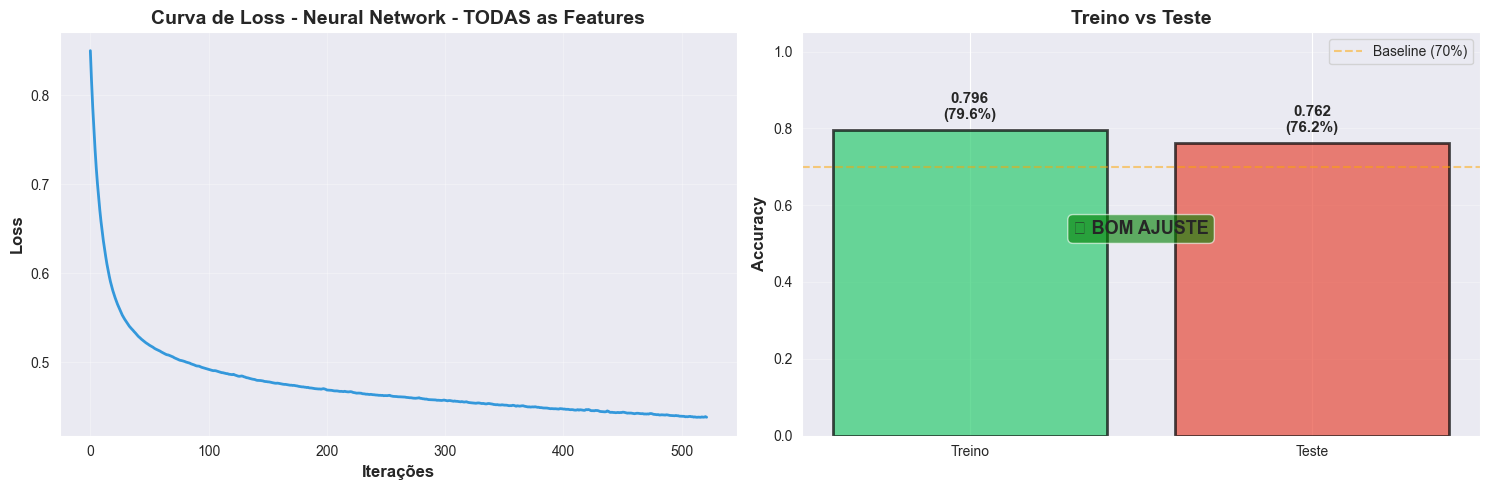

In [364]:

# Modelo base da Neural Network
nn_clf = MLPClassifier(
    hidden_layer_sizes=(32,),   
    activation='relu',           
    solver='adam',              
    alpha=0.05,                 
    learning_rate='adaptive',     
    max_iter=600,                 
    random_state=42
)

# Treinar com os dados normalizados
nn_clf.fit(X_train_scaled, y_train)

resultados_nn = diagnosticar_neural_network(
    modelo=nn_clf,
    X_train=X_train_scaled,
    X_test=X_test_scaled,
    y_train=y_train,
    y_test=y_test,
    nome_modelo="Neural Network - TODAS as Features"
)


Fazer previsões


📊 AVALIAÇÃO COMPLETA: Neural Network - Todas as Features

🎯 MÉTRICAS GLOBAIS (Weighted Average):
--------------------------------------------------------------------------------
   Accuracy:  0.7618 (76.18%)
   Precision: 0.7666 (76.66%)
   Recall:    0.7618 (76.18%)
   F1-Score:  0.7618 (76.18%)
   ROC AUC:   0.8442

📈 MÉTRICAS POR CLASSE:
--------------------------------------------------------------------------------
Classe     Precision    Recall       F1-Score     Support   
--------------------------------------------------------------------------------
0          0.7207       0.8063       0.7611       160       
1          0.8075       0.7222       0.7625       180       
--------------------------------------------------------------------------------

📋 CLASSIFICATION REPORT (Detalhado):
--------------------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.72      0.81      0.76       160
  

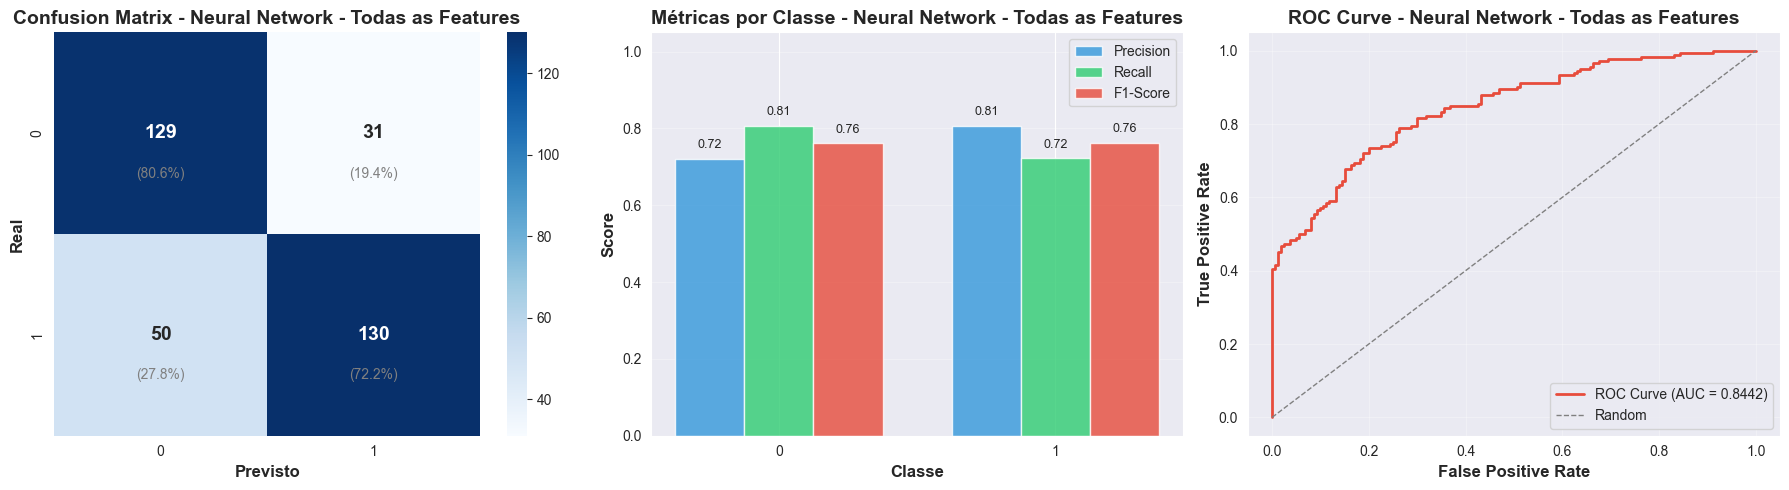


🔍 ANÁLISE DE ERROS:
--------------------------------------------------------------------------------
   Total de previsões: 340
   Acertos: 259 (76.18%)
   Erros: 81 (23.82%)

   Distribuição de Erros:
      Classe 0: 31/160 (19.4% de erro)
      Classe 1: 50/180 (27.8% de erro)



In [365]:
metricas_nn = avaliar_modelo(
    modelo=nn_clf,
    X_test=X_test_scaled,
    y_test=y_test,
    nome_modelo="Neural Network - Todas as Features"
)

## Random Forest

## Criar o modelo Random Forest

In [366]:
rf_clf = RandomForestClassifier(
    n_estimators=300,     # número de árvores
    max_depth=None,       # deixa as árvores crescerem totalmente
    min_samples_split=2,
    min_samples_leaf=1,
    bootstrap=True,
    random_state=42,
    n_jobs=-1             # usar todos os CPUs
)

treinar e prever



📊 AVALIAÇÃO COMPLETA: Random Forest - Todas as Features

🎯 MÉTRICAS GLOBAIS (Weighted Average):
--------------------------------------------------------------------------------
   Accuracy:  0.7500 (75.00%)
   Precision: 0.7520 (75.20%)
   Recall:    0.7500 (75.00%)
   F1-Score:  0.7502 (75.02%)
   ROC AUC:   0.8452

📈 MÉTRICAS POR CLASSE:
--------------------------------------------------------------------------------
Classe     Precision    Recall       F1-Score     Support   
--------------------------------------------------------------------------------
0          0.7193       0.7688       0.7432       160       
1          0.7811       0.7333       0.7564       180       
--------------------------------------------------------------------------------

📋 CLASSIFICATION REPORT (Detalhado):
--------------------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.72      0.77      0.74       160
   

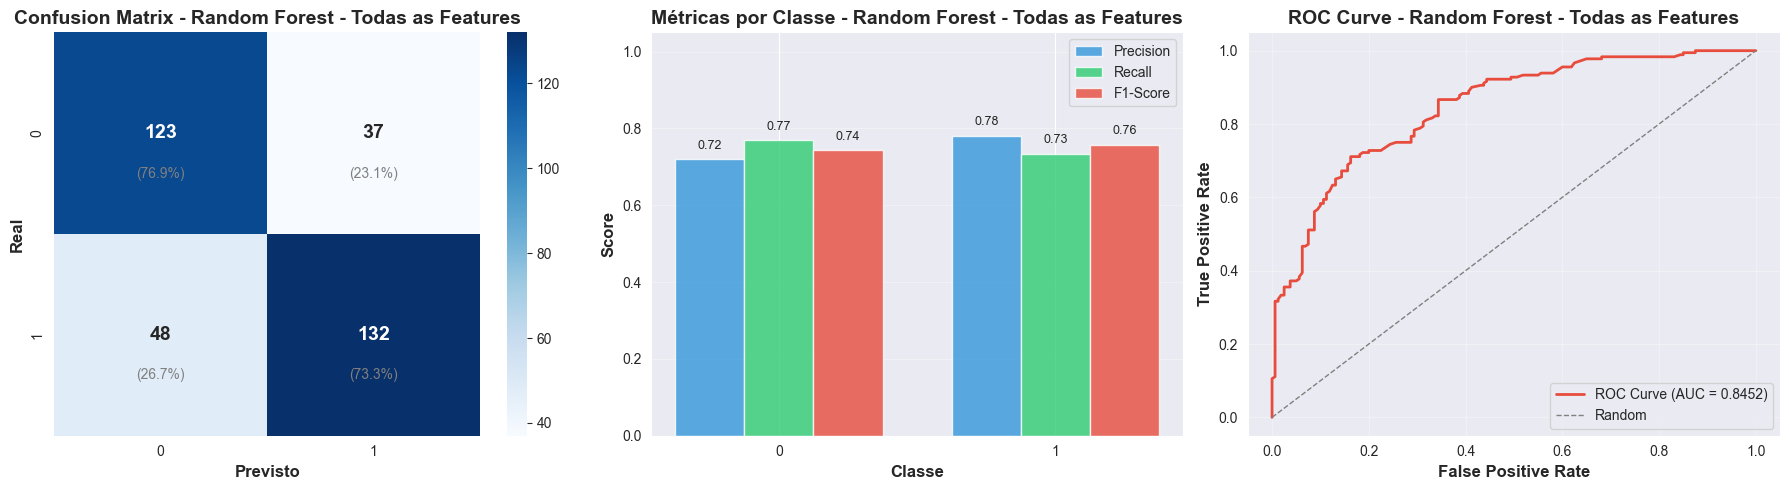


🔍 ANÁLISE DE ERROS:
--------------------------------------------------------------------------------
   Total de previsões: 340
   Acertos: 255 (75.00%)
   Erros: 85 (25.00%)

   Distribuição de Erros:
      Classe 0: 37/160 (23.1% de erro)
      Classe 1: 48/180 (26.7% de erro)



In [367]:
rf_clf.fit(X_train_scaled, y_train)

metricas_rf = avaliar_modelo(
    modelo=rf_clf,
    X_test=X_test_scaled,
    y_test=y_test,
    nome_modelo="Random Forest - Todas as Features"
)

## Support Vector Machine (SVM)

In [368]:
## Support Vector Machine (SVM)


from sklearn.svm import SVC

svm_clf = SVC(
    kernel='rbf',  # kernel mais comum e eficaz
    C=1,  # força da regularização
    gamma='scale',  # gamma automática
    probability=True,  # necessário para curva ROC
    random_state=42
)


treinar e prever


📊 AVALIAÇÃO COMPLETA: SVM (RBF) - Todas as Features

🎯 MÉTRICAS GLOBAIS (Weighted Average):
--------------------------------------------------------------------------------
   Accuracy:  0.7618 (76.18%)
   Precision: 0.7658 (76.58%)
   Recall:    0.7618 (76.18%)
   F1-Score:  0.7619 (76.19%)
   ROC AUC:   0.8368

📈 MÉTRICAS POR CLASSE:
--------------------------------------------------------------------------------
Classe     Precision    Recall       F1-Score     Support   
--------------------------------------------------------------------------------
0          0.7232       0.8000       0.7596       160       
1          0.8037       0.7278       0.7638       180       
--------------------------------------------------------------------------------

📋 CLASSIFICATION REPORT (Detalhado):
--------------------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.72      0.80      0.76       160
       

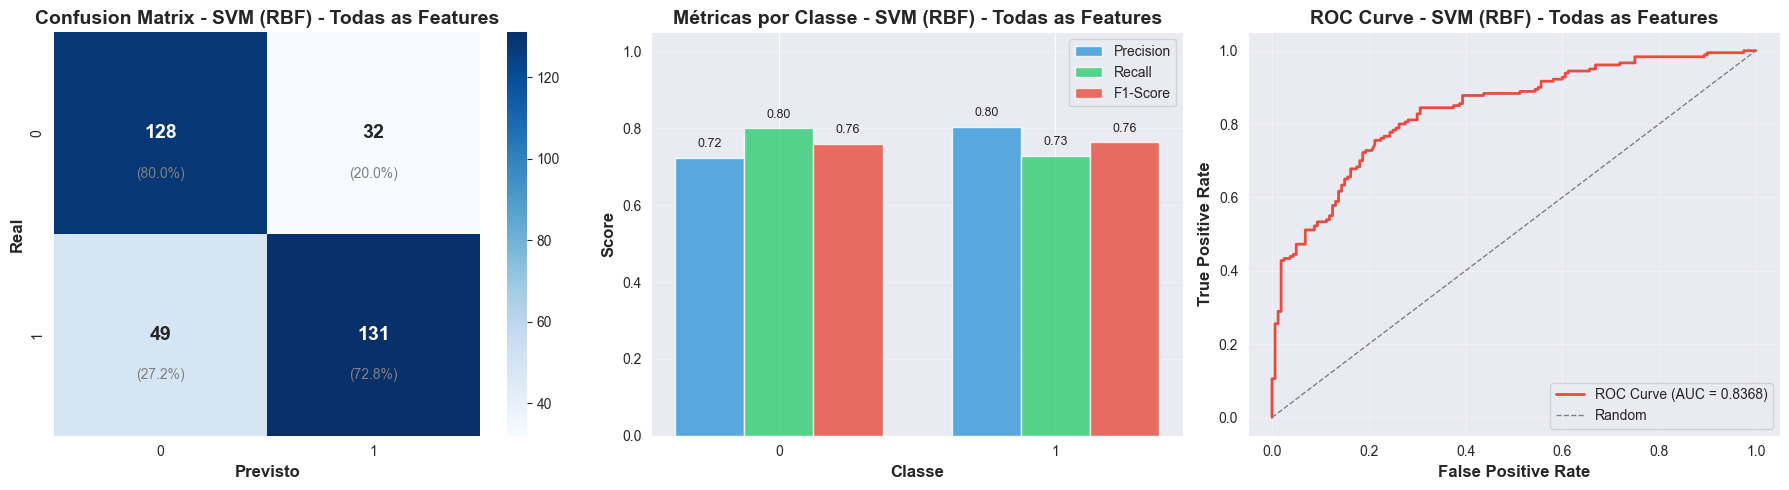


🔍 ANÁLISE DE ERROS:
--------------------------------------------------------------------------------
   Total de previsões: 340
   Acertos: 259 (76.18%)
   Erros: 81 (23.82%)

   Distribuição de Erros:
      Classe 0: 32/160 (20.0% de erro)
      Classe 1: 49/180 (27.2% de erro)



In [369]:

svm_clf.fit(X_train_scaled, y_train)

metricas_svm = avaliar_modelo(
    modelo=svm_clf,
    X_test=X_test_scaled,
    y_test=y_test,
    nome_modelo="SVM (RBF) - Todas as Features"
)


## Importância das Features (Random Forest)

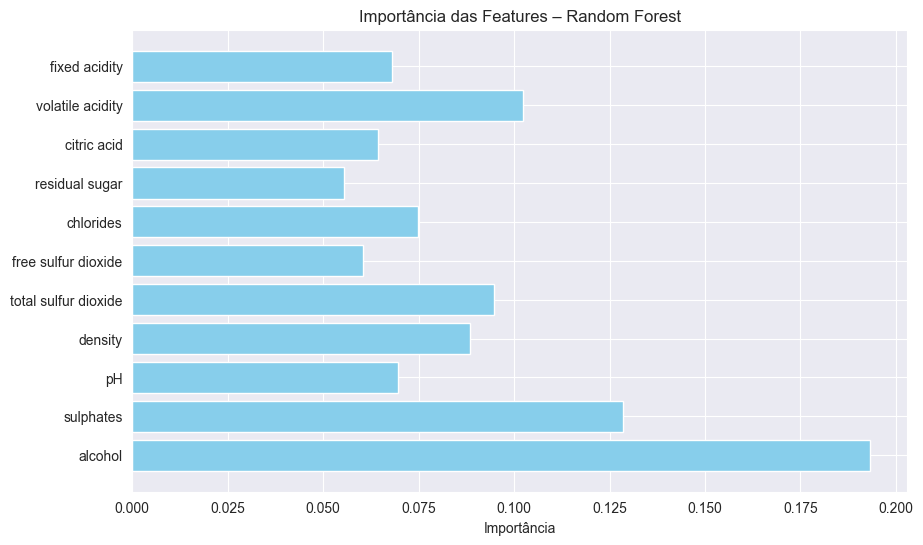

In [370]:
feature_importances = rf_clf.feature_importances_
features = X.columns

plt.figure(figsize=(10, 6))
plt.barh(features, feature_importances, color='skyblue')
plt.xlabel("Importância")
plt.title("Importância das Features – Random Forest")
plt.gca().invert_yaxis()
plt.show()

## Feature Selection – Mutual Information

=== Mutual Information Ranking ===
                 Feature  MI Score
10               alcohol  0.121199
9              sulphates  0.083922
1       volatile acidity  0.054853
6   total sulfur dioxide  0.038169
7                density  0.023337
3         residual sugar  0.015462
4              chlorides  0.012903
8                     pH  0.010867
0          fixed acidity  0.009165
2            citric acid  0.007717
5    free sulfur dioxide  0.000000


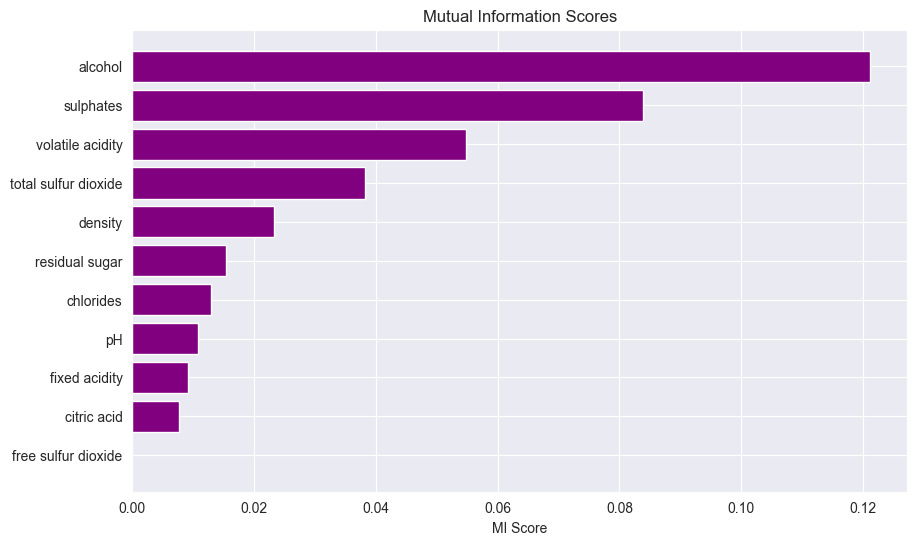

In [371]:

from sklearn.feature_selection import mutual_info_classif
import numpy as np

# Mutual Information (usa dados NÃO normalizados)
mi_scores = mutual_info_classif(X, y, random_state=42)

mi_df = pd.DataFrame({
    'Feature': X.columns,
    'MI Score': mi_scores
}).sort_values(by='MI Score', ascending=False)

print("=== Mutual Information Ranking ===")
print(mi_df)

# Plot
plt.figure(figsize=(10, 6))
plt.barh(mi_df['Feature'], mi_df['MI Score'], color='purple')
plt.title("Mutual Information Scores")
plt.xlabel("MI Score")
plt.gca().invert_yaxis()
plt.show()


## Feature Selection – Permutation Importance (Neural Network)

=== Permutation Importance (NN) ===
                 Feature  Importance
10               alcohol    0.118039
9              sulphates    0.053137
6   total sulfur dioxide    0.042745
5    free sulfur dioxide    0.020392
1       volatile acidity    0.017647
7                density    0.016471
2            citric acid    0.010588
4              chlorides    0.010196
0          fixed acidity    0.002157
3         residual sugar    0.000980
8                     pH   -0.000588


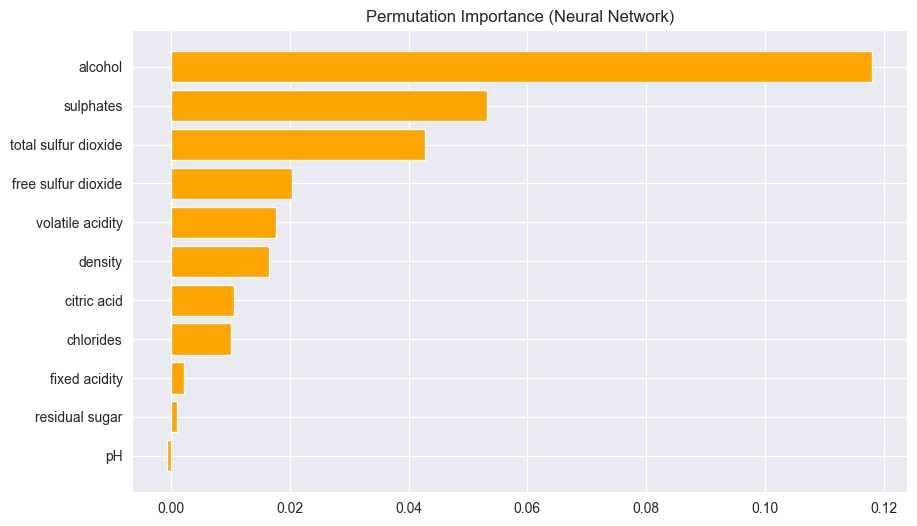

In [372]:
from sklearn.inspection import permutation_importance

perm_result = permutation_importance(
    nn_clf,  # a tua neural network treinada
    X_test_scaled,
    y_test,
    n_repeats=15,
    random_state=42,
    n_jobs=-1
)

perm_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': perm_result.importances_mean
}).sort_values(by='Importance', ascending=False)

print("=== Permutation Importance (NN) ===")
print(perm_df)

plt.figure(figsize=(10, 6))
plt.barh(perm_df['Feature'], perm_df['Importance'], color='orange')
plt.title("Permutation Importance (Neural Network)")
plt.gca().invert_yaxis()
plt.show()


# Fazer sem [citric acid, chlorides, free sulfur dioxide]

In [373]:
## Remover features fracas: citric acid, chlorides, free sulfur dioxide

features_to_drop = ['citric acid', 'chlorides', 'free sulfur dioxide']

wine_data_reduced = wine_data_bi.drop(columns=features_to_drop)

wine_data_reduced.head()


,fixed acidity,volatile acidity,residual sugar,total sulfur dioxide,density,pH,sulphates,alcohol,Target
0,7.4,0.70,1.9,34.0,0.9978,3.51,0.56,9.4,0
1,7.8,0.88,2.6,67.0,0.9968,3.20,0.68,9.8,0
2,7.8,0.76,2.3,54.0,0.9970,3.26,0.65,9.8,0
3,11.2,0.28,1.9,60.0,0.9980,3.16,0.58,9.8,1
5,7.4,0.66,1.8,40.0,0.9978,3.51,0.56,9.4,0


## Neural Network

In [374]:
## Separar X e y para o dataset reduzido
X_red = wine_data_reduced.drop(columns=['Target'])
y_red = wine_data_reduced['Target']

## Train/Test Split (dataset reduzido)
from sklearn.model_selection import train_test_split

X_train_red, X_test_red, y_train_red, y_test_red = train_test_split(
    X_red,
    y_red,
    test_size=0.25,
    random_state=42,
    stratify=y_red
)

## Normalização (apenas com dados reduzidos)
from sklearn.preprocessing import StandardScaler

scaler_red = StandardScaler()
X_train_red_scaled = scaler_red.fit_transform(X_train_red)
X_test_red_scaled = scaler_red.transform(X_test_red)


## TREINAR NEURAL NETWORK (SEM FEATURES FRACAS)

📊 DIAGNÓSTICO: Neural Network - Features Reduzidas

1️⃣ PERFORMANCE:
   Accuracy TREINO: 0.7821 (78.21%)
   Accuracy TESTE:  0.7647 (76.47%)
   Gap (diferença): 0.0174 (1.74%)

2️⃣ CONVERGÊNCIA:
   Iterações usadas: 397 / 600
   ✅ Modelo convergiu antes do limite
   Loss final: 0.466626
   ✅ Loss estabilizado (std=0.0003)

3️⃣ DIAGNÓSTICO:
   ✅ BOM AJUSTE
   📌 Modelo bem equilibrado (gap = 0.0174)

   ➡️  PRÓXIMOS PASSOS:
      1. Fazer Grid Search para fine-tuning
      2. Testar arquiteturas ligeiramente diferentes
      3. Validar com cross-validation



C:\Users\edupe\AppData\Local\Temp\ipykernel_27824\1123633683.py:181: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\edupe\PyCharmMiscProject\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


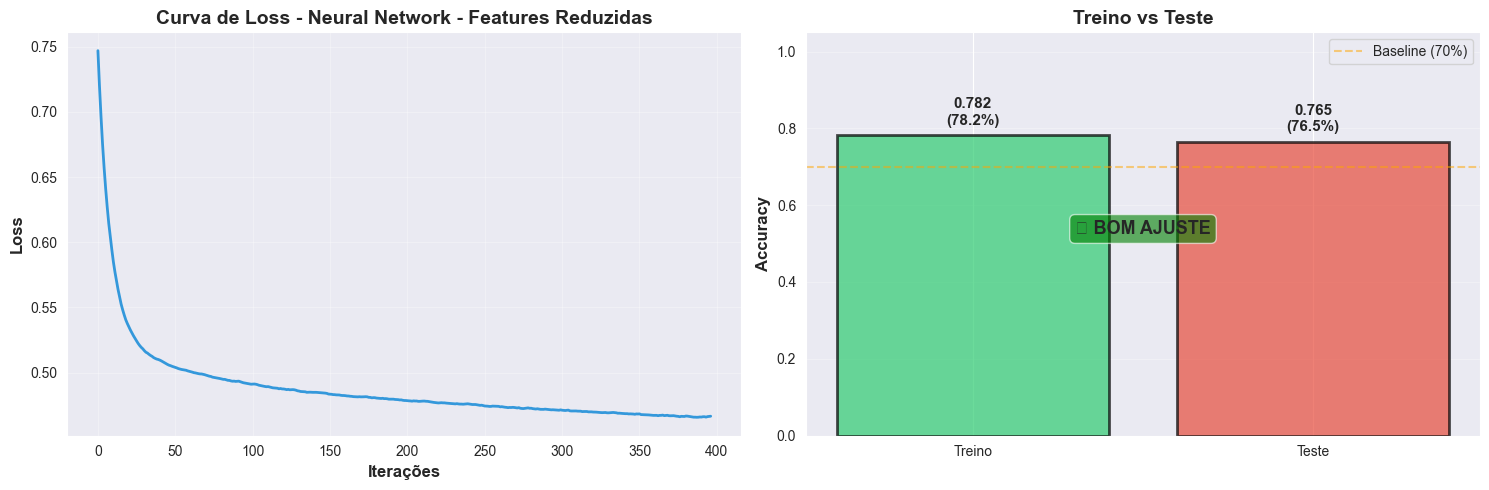

=== Neural Network (Reduced Features) ===
              precision    recall  f1-score   support

           0       0.72      0.81      0.76       160
           1       0.81      0.72      0.76       180

    accuracy                           0.76       340
   macro avg       0.77      0.77      0.76       340
weighted avg       0.77      0.76      0.76       340

Confusion Matrix:
 [[130  30]
 [ 50 130]]
Accuracy:  0.7647
Precision: 0.8125
Recall:    0.7222
F1 Score:  0.7647


In [375]:
## Neural Network (dataset reduzido)
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, \
    classification_report

nn_red = MLPClassifier(
    hidden_layer_sizes=(32),   
    activation='relu',           
    solver='adam',              
    alpha=0.05,                 
    learning_rate='adaptive',     
    max_iter=600,                 
    random_state=42
)

# Treinar
nn_red.fit(X_train_red_scaled, y_train_red)


resultados_nn_red = diagnosticar_neural_network(
    modelo=nn_red,
    X_train=X_train_red_scaled,
    X_test=X_test_red_scaled,
    y_train=y_train_red,
    y_test=y_test_red,
    nome_modelo="Neural Network - Features Reduzidas"
)


# Previsões
nn_red_preds = nn_red.predict(X_test_red_scaled)

# Métricas
print("=== Neural Network (Reduced Features) ===")
print(classification_report(y_test_red, nn_red_preds))
print("Confusion Matrix:\n", confusion_matrix(y_test_red, nn_red_preds))

nn_acc_red = accuracy_score(y_test_red, nn_red_preds)
nn_prec_red = precision_score(y_test_red, nn_red_preds)
nn_rec_red = recall_score(y_test_red, nn_red_preds)
nn_f1_red = f1_score(y_test_red, nn_red_preds)

print(f"Accuracy:  {nn_acc_red:.4f}")
print(f"Precision: {nn_prec_red:.4f}")
print(f"Recall:    {nn_rec_red:.4f}")
print(f"F1 Score:  {nn_f1_red:.4f}")


## TREINAR RANDOM FOREST (SEM FEATURES FRACAS)

In [376]:
## Random Forest (dataset reduzido)
from sklearn.ensemble import RandomForestClassifier

rf_red = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

# Treinar
rf_red.fit(X_train_red, y_train_red)

# Prever
rf_red_preds = rf_red.predict(X_test_red)

# Métricas
print("=== Random Forest (Reduced Features) ===")
print(classification_report(y_test_red, rf_red_preds))
print("Confusion Matrix:\n", confusion_matrix(y_test_red, rf_red_preds))

rf_acc_red = accuracy_score(y_test_red, rf_red_preds)
rf_prec_red = precision_score(y_test_red, rf_red_preds)
rf_rec_red = recall_score(y_test_red, rf_red_preds)
rf_f1_red = f1_score(y_test_red, rf_red_preds)

print(f"Accuracy:  {rf_acc_red:.4f}")
print(f"Precision: {rf_prec_red:.4f}")
print(f"Recall:    {rf_rec_red:.4f}")
print(f"F1 Score:  {rf_f1_red:.4f}")


=== Random Forest (Reduced Features) ===
              precision    recall  f1-score   support

           0       0.74      0.79      0.76       160
           1       0.80      0.76      0.78       180

    accuracy                           0.77       340
   macro avg       0.77      0.77      0.77       340
weighted avg       0.77      0.77      0.77       340

Confusion Matrix:
 [[126  34]
 [ 44 136]]
Accuracy:  0.7706
Precision: 0.8000
Recall:    0.7556
F1 Score:  0.7771


## TREINAR SVM (SEM FEATURES FRACAS)

In [377]:
## TREINAR SVM (SEM FEATURES FRACAS)


from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

# Modelo SVM (dataset reduzido)
svm_red = SVC(
    kernel='rbf',
    C=1,
    gamma='scale',
    probability=True,
    random_state=42
)

# Treinar com dados reduzidos (normalizados)
svm_red.fit(X_train_red_scaled, y_train_red)

# Prever
svm_red_preds = svm_red.predict(X_test_red_scaled)

# Métricas
print("=== SVM (Reduced Features) ===")
print(classification_report(y_test_red, svm_red_preds))
print("Confusion Matrix:\n", confusion_matrix(y_test_red, svm_red_preds))

svm_acc_red = accuracy_score(y_test_red, svm_red_preds)
svm_prec_red = precision_score(y_test_red, svm_red_preds)
svm_rec_red = recall_score(y_test_red, svm_red_preds)
svm_f1_red = f1_score(y_test_red, svm_red_preds)

print(f"Accuracy:  {svm_acc_red:.4f}")
print(f"Precision: {svm_prec_red:.4f}")
print(f"Recall:    {svm_rec_red:.4f}")
print(f"F1 Score:  {svm_f1_red:.4f}")


=== SVM (Reduced Features) ===
              precision    recall  f1-score   support

           0       0.73      0.81      0.77       160
           1       0.82      0.74      0.78       180

    accuracy                           0.77       340
   macro avg       0.78      0.78      0.77       340
weighted avg       0.78      0.77      0.77       340

Confusion Matrix:
 [[130  30]
 [ 47 133]]
Accuracy:  0.7735
Precision: 0.8160
Recall:    0.7389
F1 Score:  0.7755


# Feature Engeneering

In [378]:
## FEATURE ENGINEERING

df_fe = wine_data_bi.copy()  # criar uma cópia para engenieria de features

# 1. Relação de dióxidos de enxofre
df_fe['SO2_ratio'] = df_fe['free sulfur dioxide'] / (df_fe['total sulfur dioxide'] + 1e-6)

# 2. Acidity index (acidez relativa ao pH)
df_fe['acidity_index'] = df_fe['fixed acidity'] / (df_fe['pH'] + 1e-6)

# 3. Relação álcool - densidade
df_fe['alc_density_diff'] = df_fe['alcohol'] - df_fe['density']

# 4. Total acidity (soma de acidezes)
df_fe['total_acidity'] = (
        df_fe['fixed acidity'] +
        df_fe['volatile acidity'] +
        df_fe['citric acid']
)

# 5. Normalizar sulfatos pelo álcool
df_fe['sulphates_per_alc'] = df_fe['sulphates'] / (df_fe['alcohol'] + 1e-6)

# 6. Log transforms para colunas com long tail
for col in ['residual sugar', 'chlorides', 'sulphates', 'total sulfur dioxide']:
    df_fe[f'log_{col.replace(" ", "_")}'] = np.log1p(df_fe[col])

df_fe.head()


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,...,Target,SO2_ratio,acidity_index,alc_density_diff,total_acidity,sulphates_per_alc,log_residual_sugar,log_chlorides,log_sulphates,log_total_sulfur_dioxide
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,...,0,0.323529,2.108262,8.4022,8.10,0.059574,1.064711,0.073250,0.444686,3.555348
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,...,0,0.373134,2.437499,8.8032,8.68,0.069388,1.280934,0.093490,0.518794,4.219508
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,...,0,0.277778,2.392637,8.8030,8.60,0.066327,1.193922,0.088011,0.500775,4.007333
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,...,1,0.283333,3.544303,8.8020,12.04,0.059184,1.064711,0.072321,0.457425,4.110874
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,...,0,0.325000,2.108262,8.4022,8.06,0.059574,1.029619,0.072321,0.444686,3.713572


## Neural Network com novas features

📊 DIAGNÓSTICO: Neural Network - Feature Engineering

1️⃣ PERFORMANCE:
   Accuracy TREINO: 0.7998 (79.98%)
   Accuracy TESTE:  0.7647 (76.47%)
   Gap (diferença): 0.0351 (3.51%)

2️⃣ CONVERGÊNCIA:
   Iterações usadas: 389 / 600
   ✅ Modelo convergiu antes do limite
   Loss final: 0.432042
   ✅ Loss estabilizado (std=0.0004)

3️⃣ DIAGNÓSTICO:
   ✅ BOM AJUSTE
   📌 Modelo bem equilibrado (gap = 0.0351)

   ➡️  PRÓXIMOS PASSOS:
      1. Fazer Grid Search para fine-tuning
      2. Testar arquiteturas ligeiramente diferentes
      3. Validar com cross-validation



C:\Users\edupe\AppData\Local\Temp\ipykernel_27824\1123633683.py:181: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\edupe\PyCharmMiscProject\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


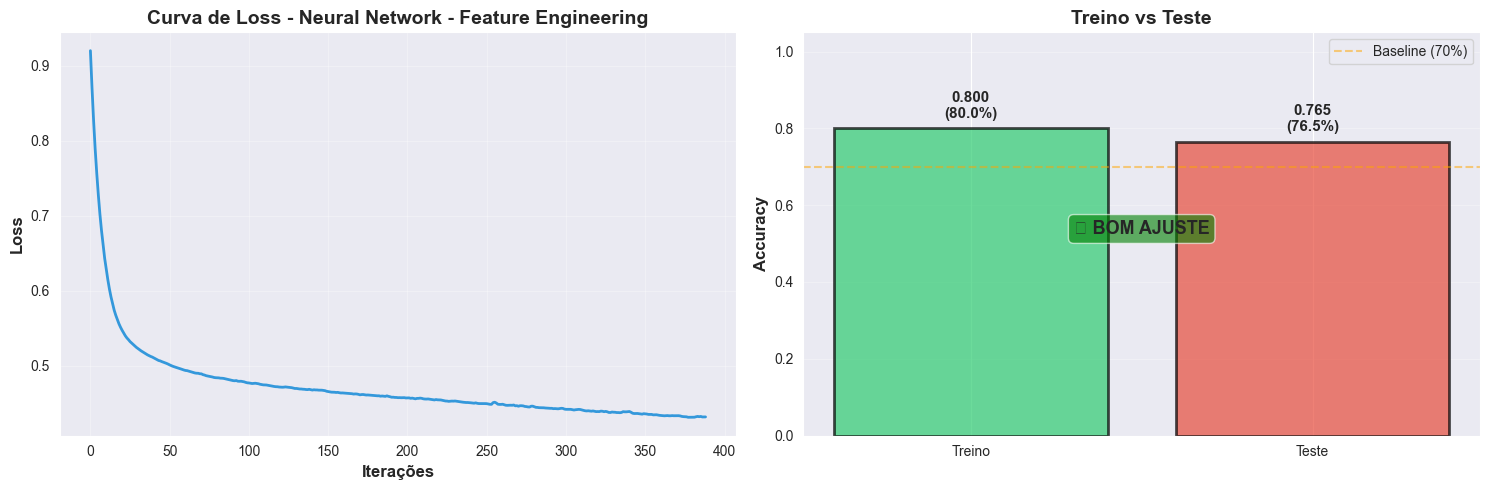

=== Neural Network (Feature Engineering) ===
              precision    recall  f1-score   support

           0       0.72      0.81      0.76       160
           1       0.81      0.72      0.76       180

    accuracy                           0.76       340
   macro avg       0.77      0.77      0.76       340
weighted avg       0.77      0.76      0.76       340

Confusion Matrix:
 [[130  30]
 [ 50 130]]

Accuracy : 0.7647
Precision: 0.8125
Recall   : 0.7222
F1 Score : 0.7647


In [379]:
## Separar X e y (dataset com feature engineering)
X_fe = df_fe.drop(columns=['Target'])
y_fe = df_fe['Target']

## Train/Test Split
from sklearn.model_selection import train_test_split

X_train_fe, X_test_fe, y_train_fe, y_test_fe = train_test_split(
    X_fe, y_fe,
    test_size=0.25,
    random_state=42,
    stratify=y_fe
)

## Normalização para NN
from sklearn.preprocessing import StandardScaler

scaler_fe = StandardScaler()
X_train_fe_scaled = scaler_fe.fit_transform(X_train_fe)
X_test_fe_scaled = scaler_fe.transform(X_test_fe)

## Neural Network (com feature engineering)
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, \
    f1_score

nn_fe = MLPClassifier(
    hidden_layer_sizes=(32,),   
    activation='relu',           
    solver='adam',              
    alpha=0.05,                 
    learning_rate='adaptive',     
    max_iter=600,                 
    random_state=42
)

# Treinar
nn_fe.fit(X_train_fe_scaled, y_train_fe)

resultados_nn_fe = diagnosticar_neural_network(
    modelo=nn_fe,
    X_train=X_train_fe_scaled,
    X_test=X_test_fe_scaled,
    y_train=y_train_fe,
    y_test=y_test_fe,
    nome_modelo="Neural Network - Feature Engineering"
)

# Previsões
nn_preds_fe = nn_fe.predict(X_test_fe_scaled)

print("=== Neural Network (Feature Engineering) ===")
print(classification_report(y_test_fe, nn_preds_fe))
print("Confusion Matrix:\n", confusion_matrix(y_test_fe, nn_preds_fe))

nn_acc = accuracy_score(y_test_fe, nn_preds_fe)
nn_prec = precision_score(y_test_fe, nn_preds_fe)
nn_rec = recall_score(y_test_fe, nn_preds_fe)
nn_f1 = f1_score(y_test_fe, nn_preds_fe)

print(f"\nAccuracy : {nn_acc:.4f}")
print(f"Precision: {nn_prec:.4f}")
print(f"Recall   : {nn_rec:.4f}")
print(f"F1 Score : {nn_f1:.4f}")


## Random Forest com novas features

In [380]:
## Random Forest (com feature engineering)
from sklearn.ensemble import RandomForestClassifier

rf_fe = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

# Treinar
rf_fe.fit(X_train_fe, y_train_fe)

# Previsões
rf_preds_fe = rf_fe.predict(X_test_fe)

print("=== Random Forest (Feature Engineering) ===")
print(classification_report(y_test_fe, rf_preds_fe))
print("Confusion Matrix:\n", confusion_matrix(y_test_fe, rf_preds_fe))

rf_acc = accuracy_score(y_test_fe, rf_preds_fe)
rf_prec = precision_score(y_test_fe, rf_preds_fe)
rf_rec = recall_score(y_test_fe, rf_preds_fe)
rf_f1 = f1_score(y_test_fe, rf_preds_fe)

print(f"\nAccuracy : {rf_acc:.4f}")
print(f"Precision: {rf_prec:.4f}")
print(f"Recall   : {rf_rec:.4f}")
print(f"F1 Score : {rf_f1:.4f}")


=== Random Forest (Feature Engineering) ===
              precision    recall  f1-score   support

           0       0.74      0.78      0.76       160
           1       0.79      0.75      0.77       180

    accuracy                           0.76       340
   macro avg       0.76      0.77      0.76       340
weighted avg       0.77      0.76      0.76       340

Confusion Matrix:
 [[125  35]
 [ 45 135]]

Accuracy : 0.7647
Precision: 0.7941
Recall   : 0.7500
F1 Score : 0.7714


## SVM com Novas Features

In [381]:
#SVM com Feature Engineering

from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

# Criar modelo SVM (com engineered features)
svm_fe = SVC(
    kernel='rbf',
    C=1,
    gamma='scale',
    probability=True,
    random_state=42
)

# Treinar (usar dados normalizados)
svm_fe.fit(X_train_fe_scaled, y_train_fe)

# Prever
svm_preds_fe = svm_fe.predict(X_test_fe_scaled)

print("=== SVM (Feature Engineering) ===")
print(classification_report(y_test_fe, svm_preds_fe))
print("Confusion Matrix:\n", confusion_matrix(y_test_fe, svm_preds_fe))

svm_acc_fe = accuracy_score(y_test_fe, svm_preds_fe)
svm_prec_fe = precision_score(y_test_fe, svm_preds_fe)
svm_rec_fe = recall_score(y_test_fe, svm_preds_fe)
svm_f1_fe = f1_score(y_test_fe, svm_preds_fe)

print(f"\nAccuracy : {svm_acc_fe:.4f}")
print(f"Precision: {svm_prec_fe:.4f}")
print(f"Recall   : {svm_rec_fe:.4f}")
print(f"F1 Score : {svm_f1_fe:.4f}")


=== SVM (Feature Engineering) ===
              precision    recall  f1-score   support

           0       0.71      0.78      0.74       160
           1       0.79      0.72      0.75       180

    accuracy                           0.75       340
   macro avg       0.75      0.75      0.75       340
weighted avg       0.75      0.75      0.75       340

Confusion Matrix:
 [[125  35]
 [ 51 129]]

Accuracy : 0.7471
Precision: 0.7866
Recall   : 0.7167
F1 Score : 0.7500


## MUTUAL INFORMATION COM ENGINEERED FEATURES

=== MUTUAL INFORMATION (Feature Engineering) ===
                     Feature  MI Score
10                   alcohol  0.140360
13          alc_density_diff  0.131559
18             log_sulphates  0.075196
1           volatile acidity  0.062316
15         sulphates_per_alc  0.055709
9                  sulphates  0.051473
6       total sulfur dioxide  0.048742
19  log_total_sulfur_dioxide  0.040029
11                 SO2_ratio  0.038236
5        free sulfur dioxide  0.033255
4                  chlorides  0.031395
7                    density  0.019032
0              fixed acidity  0.017237
12             acidity_index  0.012697
3             residual sugar  0.008812
14             total_acidity  0.005170
8                         pH  0.002387
17             log_chlorides  0.000555
2                citric acid  0.000000
16        log_residual_sugar  0.000000


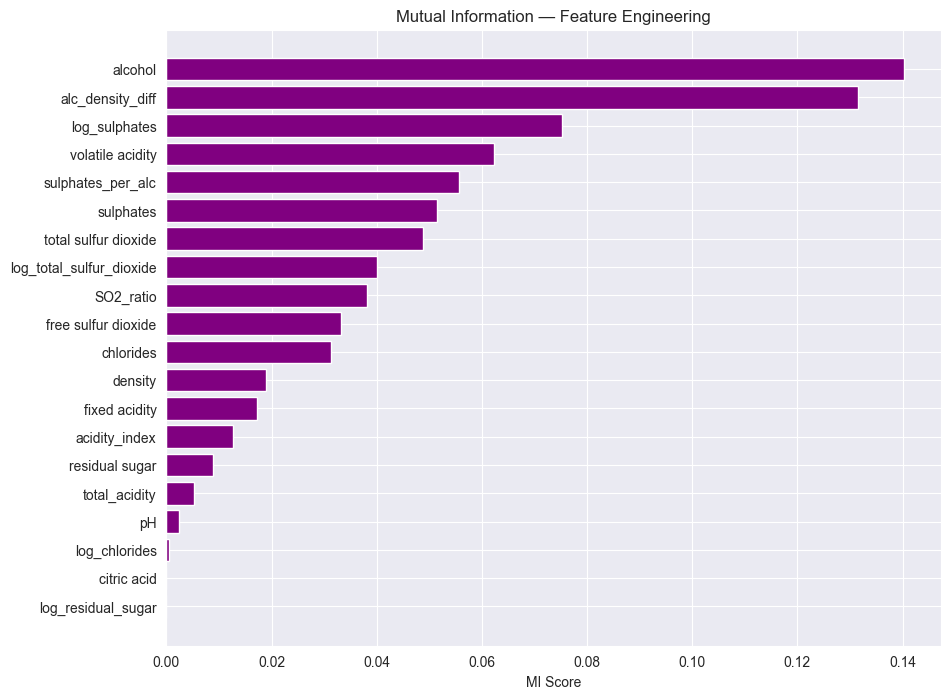

In [382]:
## MUTUAL INFORMATION — Feature Engineering

from sklearn.feature_selection import mutual_info_classif
import pandas as pd
import matplotlib.pyplot as plt

# Calcular MI
mi_scores_fe = mutual_info_classif(X_fe, y_fe, random_state=42)

# Criar DataFrame ordenado
mi_df_fe = pd.DataFrame({
    'Feature': X_fe.columns,
    'MI Score': mi_scores_fe
}).sort_values(by="MI Score", ascending=False)

print("=== MUTUAL INFORMATION (Feature Engineering) ===")
print(mi_df_fe)

# Gráfico
plt.figure(figsize=(10, 8))
plt.barh(mi_df_fe['Feature'], mi_df_fe['MI Score'], color='purple')
plt.gca().invert_yaxis()
plt.title("Mutual Information — Feature Engineering")
plt.xlabel("MI Score")
plt.show()


## RANDOM FOREST IMPORTANCE (com engineered features)

=== RANDOM FOREST IMPORTANCE (Feature Engineering) ===
                     Feature  Importance
13          alc_density_diff    0.129567
10                   alcohol    0.098880
1           volatile acidity    0.063347
9                  sulphates    0.058796
18             log_sulphates    0.058007
6       total sulfur dioxide    0.049643
7                    density    0.048611
19  log_total_sulfur_dioxide    0.047675
11                 SO2_ratio    0.047356
15         sulphates_per_alc    0.046136
12             acidity_index    0.042813
8                         pH    0.038968
14             total_acidity    0.038760
17             log_chlorides    0.038666
4                  chlorides    0.036292
2                citric acid    0.036082
5        free sulfur dioxide    0.033834
0              fixed acidity    0.031625
3             residual sugar    0.029240
16        log_residual_sugar    0.025701


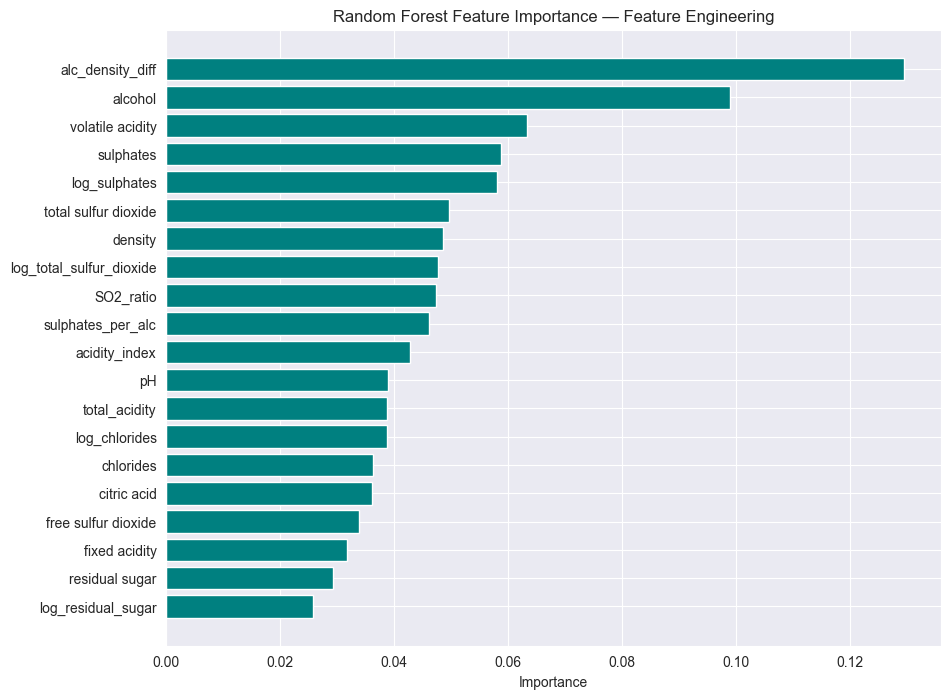

In [383]:
## RANDOM FOREST FEATURE IMPORTANCE — Feature Engineering

from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import matplotlib.pyplot as plt

# Criar e treinar o modelo
rf_fe_fs = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_fe_fs.fit(X_train_fe, y_train_fe)

# Importâncias
rf_importances_fe = rf_fe_fs.feature_importances_

# DataFrame ordenado
rf_df_fe = pd.DataFrame({
    'Feature': X_fe.columns,
    'Importance': rf_importances_fe
}).sort_values(by='Importance', ascending=False)

print("=== RANDOM FOREST IMPORTANCE (Feature Engineering) ===")
print(rf_df_fe)

# Gráfico
plt.figure(figsize=(10, 8))
plt.barh(rf_df_fe['Feature'], rf_df_fe['Importance'], color='teal')
plt.gca().invert_yaxis()
plt.title("Random Forest Feature Importance — Feature Engineering")
plt.xlabel("Importance")
plt.show()


## PERMUTATION IMPORTANCE (com engineered features)

=== PERMUTATION IMPORTANCE (Feature Engineering) ===
                     Feature  Importance
10                   alcohol    0.055098
6       total sulfur dioxide    0.038235
13          alc_density_diff    0.038235
11                 SO2_ratio    0.037451
18             log_sulphates    0.034706
12             acidity_index    0.031961
5        free sulfur dioxide    0.029608
1           volatile acidity    0.026275
7                    density    0.026275
8                         pH    0.026078
0              fixed acidity    0.026078
9                  sulphates    0.023725
15         sulphates_per_alc    0.021765
4                  chlorides    0.020784
14             total_acidity    0.019216
19  log_total_sulfur_dioxide    0.017843
17             log_chlorides    0.011373
2                citric acid    0.010980
3             residual sugar    0.007647
16        log_residual_sugar    0.002745


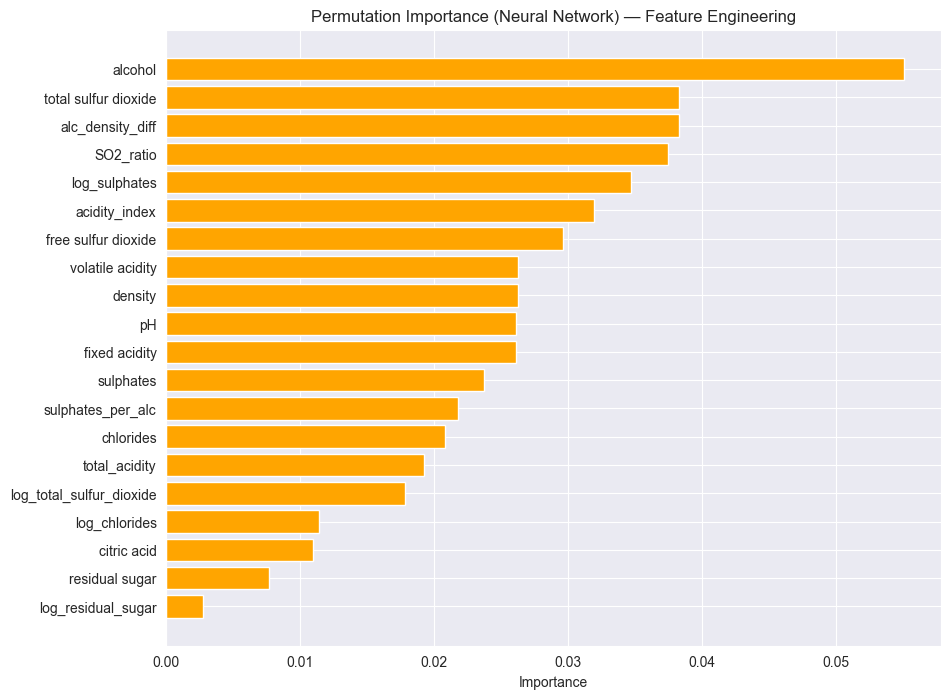

In [384]:
## PERMUTATION IMPORTANCE (NN) — Feature Engineering

from sklearn.inspection import permutation_importance
import pandas as pd
import matplotlib.pyplot as plt

# Calcular Permutation Importance
perm_fe = permutation_importance(
    nn_fe,  # modelo NN treinado com FE
    X_test_fe_scaled,  # dados de teste normalizados com FE
    y_test_fe,  # labels
    n_repeats=15,
    random_state=42,
    n_jobs=-1
)

# Criar DF ordenado por importância
perm_df_fe = pd.DataFrame({
    'Feature': X_fe.columns,
    'Importance': perm_fe.importances_mean
}).sort_values(by='Importance', ascending=False)

# Mostrar resultado
print("=== PERMUTATION IMPORTANCE (Feature Engineering) ===")
print(perm_df_fe)

# Gráfico
plt.figure(figsize=(10, 8))
plt.barh(perm_df_fe['Feature'], perm_df_fe['Importance'], color='orange')
plt.gca().invert_yaxis()
plt.title("Permutation Importance (Neural Network) — Feature Engineering")
plt.xlabel("Importance")
plt.show()


# feature SELECTION FINAL

In [385]:
## FEATURE SELECTION FINAL — TOP 10 com Voting (MI + RF + Permutation Importance)

import pandas as pd

# Top 10 de cada método
top_k = 10

mi_top10 = list(mi_df_fe.sort_values("MI Score", ascending=False).head(top_k)["Feature"])
rf_top10 = list(rf_df_fe.sort_values("Importance", ascending=False).head(top_k)["Feature"])
pi_top10 = list(perm_df_fe.sort_values("Importance", ascending=False).head(top_k)["Feature"])

print("MI TOP10:", mi_top10)
print("RF TOP10:", rf_top10)
print("PI TOP10:", pi_top10)

# Votação (Ensemble)
all_candidates = mi_top10 + rf_top10 + pi_top10

vote_count = pd.Series(all_candidates).value_counts()

# Features ordenadas pela quantidade de votos (3 → muito forte)
final_top10 = list(vote_count.head(10).index)

print("\n=== TOP 10 FEATURES SELECIONADAS ===")
for f in final_top10:
    print(" -", f)


MI TOP10: ['alcohol', 'alc_density_diff', 'log_sulphates', 'volatile acidity', 'sulphates_per_alc', 'sulphates', 'total sulfur dioxide', 'log_total_sulfur_dioxide', 'SO2_ratio', 'free sulfur dioxide']
RF TOP10: ['alc_density_diff', 'alcohol', 'volatile acidity', 'sulphates', 'log_sulphates', 'total sulfur dioxide', 'density', 'log_total_sulfur_dioxide', 'SO2_ratio', 'sulphates_per_alc']
PI TOP10: ['alcohol', 'total sulfur dioxide', 'alc_density_diff', 'SO2_ratio', 'log_sulphates', 'acidity_index', 'free sulfur dioxide', 'volatile acidity', 'density', 'pH']

=== TOP 10 FEATURES SELECIONADAS ===
 - alcohol
 - alc_density_diff
 - log_sulphates
 - volatile acidity
 - total sulfur dioxide
 - SO2_ratio
 - sulphates_per_alc
 - sulphates
 - log_total_sulfur_dioxide
 - free sulfur dioxide


# Criar dataset final com top 10 features

In [386]:
# Dataset final com as TOP 10 features
X_final = df_fe[[
    'alcohol',
    'alc_density_diff',
    'log_sulphates',
    'volatile acidity',
    'sulphates',
    'log_total_sulfur_dioxide',
    'total sulfur dioxide',
    'sulphates_per_alc',
    'SO2_ratio',
    'free sulfur dioxide'
]]

y_final = df_fe['Target']


In [387]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train_final, X_test_final, y_train_final, y_test_final = train_test_split(
    X_final, y_final, test_size=0.25, random_state=42, stratify=y_final
)

# Normalização só para NN
scaler_final = StandardScaler()
X_train_final_scaled = scaler_final.fit_transform(X_train_final)
X_test_final_scaled = scaler_final.transform(X_test_final)


## Neural network com top 10

📊 DIAGNÓSTICO: Neural Network - Top 10 Features Final

1️⃣ PERFORMANCE:
   Accuracy TREINO: 0.7763 (77.63%)
   Accuracy TESTE:  0.7676 (76.76%)
   Gap (diferença): 0.0086 (0.86%)

2️⃣ CONVERGÊNCIA:
   Iterações usadas: 133 / 600
   ✅ Modelo convergiu antes do limite
   Loss final: 0.487407
   ✅ Loss estabilizado (std=0.0002)

3️⃣ DIAGNÓSTICO:
   ✅ BOM AJUSTE
   📌 Modelo bem equilibrado (gap = 0.0086)

   ➡️  PRÓXIMOS PASSOS:
      1. Fazer Grid Search para fine-tuning
      2. Testar arquiteturas ligeiramente diferentes
      3. Validar com cross-validation



C:\Users\edupe\AppData\Local\Temp\ipykernel_27824\1123633683.py:181: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\edupe\PyCharmMiscProject\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


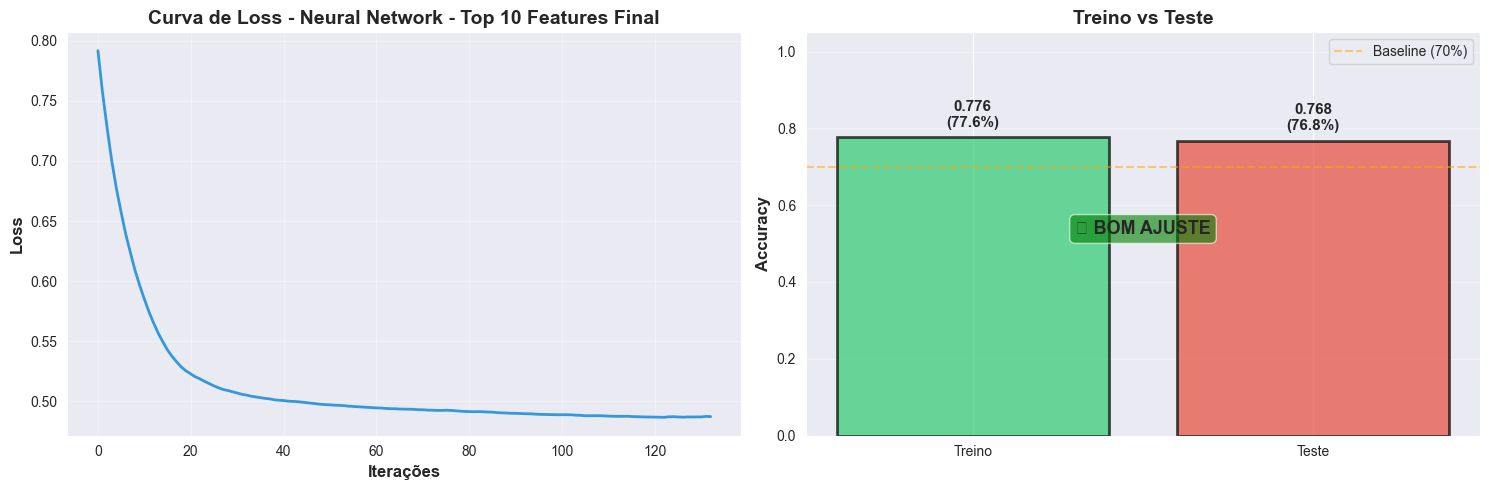

=== NEURAL NETWORK FINAL ===
              precision    recall  f1-score   support

           0       0.73      0.79      0.76       160
           1       0.80      0.74      0.77       180

    accuracy                           0.77       340
   macro avg       0.77      0.77      0.77       340
weighted avg       0.77      0.77      0.77       340

[[127  33]
 [ 46 134]]


In [388]:
from sklearn.neural_network import MLPClassifier

nn_final = MLPClassifier(
    hidden_layer_sizes=(32,),
    activation='relu',
    solver='adam',
    alpha=0.05,
    learning_rate='adaptive',
    max_iter=600,
    random_state=42
)

nn_final.fit(X_train_final_scaled, y_train_final)

resultados_nn_final = diagnosticar_neural_network(
    modelo=nn_final,
    X_train=X_train_final_scaled,
    X_test=X_test_final_scaled,
    y_train=y_train_final,
    y_test=y_test_final,
    nome_modelo="Neural Network - Top 10 Features Final"
)


nn_pred = nn_final.predict(X_test_final_scaled)

print("=== NEURAL NETWORK FINAL ===")
print(classification_report(y_test_final, nn_pred))
print(confusion_matrix(y_test_final, nn_pred))



## Random forest com Top 10

In [389]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

rf_final = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_final.fit(X_train_final, y_train_final)
rf_pred = rf_final.predict(X_test_final)

print("=== RANDOM FOREST FINAL ===")
print(classification_report(y_test_final, rf_pred))
print(confusion_matrix(y_test_final, rf_pred))


=== RANDOM FOREST FINAL ===
              precision    recall  f1-score   support

           0       0.75      0.78      0.76       160
           1       0.80      0.77      0.78       180

    accuracy                           0.77       340
   macro avg       0.77      0.77      0.77       340
weighted avg       0.77      0.77      0.77       340

[[125  35]
 [ 42 138]]


## SVM com Top10

In [390]:
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

# Criar modelo SVM (Top 10 Features)
svm_final = SVC(
    kernel='rbf',
    C=1,
    gamma='scale',
    probability=True,
    random_state=42
)

# Treinar (usar dados normalizados!)
svm_final.fit(X_train_final_scaled, y_train_final)

# Prever
svm_pred = svm_final.predict(X_test_final_scaled)

print("=== SVM FINAL (Top 10 Features) ===")
print(classification_report(y_test_final, svm_pred))
print(confusion_matrix(y_test_final, svm_pred))

# Métricas individuais (opcional)
svm_acc_final = accuracy_score(y_test_final, svm_pred)
svm_prec_final = precision_score(y_test_final, svm_pred)
svm_rec_final = recall_score(y_test_final, svm_pred)
svm_f1_final = f1_score(y_test_final, svm_pred)

print(f"\nAccuracy : {svm_acc_final:.4f}")
print(f"Precision: {svm_prec_final:.4f}")
print(f"Recall   : {svm_rec_final:.4f}")
print(f"F1 Score : {svm_f1_final:.4f}")


=== SVM FINAL (Top 10 Features) ===
              precision    recall  f1-score   support

           0       0.71      0.78      0.74       160
           1       0.79      0.71      0.75       180

    accuracy                           0.74       340
   macro avg       0.75      0.75      0.74       340
weighted avg       0.75      0.74      0.74       340

[[125  35]
 [ 52 128]]

Accuracy : 0.7441
Precision: 0.7853
Recall   : 0.7111
F1 Score : 0.7464


# Ranking features

In [391]:
# ======================================================
# RANKING COMPLETO DE FEATURES (MI + RF + PI)
# ======================================================

# 1. Mutual Information
mi_scores_all = mutual_info_classif(X_fe, y_fe, random_state=42)
mi_df_all = pd.DataFrame({'Feature': X_fe.columns, 'MI': mi_scores_all})

# 2. Random Forest Importance
rf_full = RandomForestClassifier(n_estimators=300, random_state=42)
rf_full.fit(X_fe, y_fe)
rf_importances_all = rf_full.feature_importances_
rf_df_all = pd.DataFrame({'Feature': X_fe.columns, 'RF': rf_importances_all})

# 3. Permutation Importance (NN)
perm_full = permutation_importance(
    nn_fe,
    X_test_fe_scaled,
    y_test_fe,
    n_repeats=10,
    random_state=42
)
pi_df_all = pd.DataFrame({'Feature': X_fe.columns, 'PI': perm_full.importances_mean})

# 4. Juntar tudo
ranking_full = (
    mi_df_all.merge(rf_df_all, on="Feature")
             .merge(pi_df_all, on="Feature")
)

# Normalizar cada coluna entre 0 e 1
for col in ["MI", "RF", "PI"]:
    ranking_full[col] = (ranking_full[col] - ranking_full[col].min()) / (ranking_full[col].max() - ranking_full[col].min())

# Score final = soma das importâncias normalizadas
ranking_full["Score"] = ranking_full["MI"] + ranking_full["RF"] + ranking_full["PI"]

# Ordenar da melhor para a pior
ranking_full = ranking_full.sort_values("Score", ascending=False).reset_index(drop=True)

# Ranking final (lista completa ordenada)
ranking_completo = list(ranking_full["Feature"])

print("=== RANKING COMPLETO (Top 30) ===")
print(ranking_completo[:30])


=== RANKING COMPLETO (Top 30) ===
['alcohol', 'alc_density_diff', 'log_sulphates', 'total sulfur dioxide', 'volatile acidity', 'sulphates', 'SO2_ratio', 'sulphates_per_alc', 'density', 'free sulfur dioxide', 'acidity_index', 'log_total_sulfur_dioxide', 'chlorides', 'fixed acidity', 'pH', 'total_acidity', 'log_chlorides', 'citric acid', 'residual sugar', 'log_residual_sugar']


# Top8 Top10 Top12

In [392]:
def testar_top_k(df, target, ranking, topks=[8, 10, 12]):
    """
    Testa vários valores de TopK features usando:
      - Random Forest (normalizado)
      - Neural Network
      - SVM
    Retorna um DataFrame organizado com Modelo / TopK / Métricas.
    """

    resultados = []

    for k in topks:
        print(f"\n======================\n   TESTAR TOP {k}\n======================")

        # Selecionar as k melhores features
        selected = ranking[:k]
        X = df[selected]
        y = df[target]

        # Train/Test Split
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.25, random_state=42, stratify=y
        )

        # Normalização
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        # ---------------------------------------------
        # Random Forest
        # ---------------------------------------------
        rf = RandomForestClassifier(n_estimators=300, random_state=42)
        rf.fit(X_train_scaled, y_train)
        rf_pred = rf.predict(X_test_scaled)

        resultados.append([
            "RandomForest", k,
            accuracy_score(y_test, rf_pred),
            precision_score(y_test, rf_pred, zero_division=0),
            recall_score(y_test, rf_pred, zero_division=0),
            f1_score(y_test, rf_pred, zero_division=0)
        ])

        # ---------------------------------------------
        # Neural Network
        # ---------------------------------------------
        nn = MLPClassifier(
            hidden_layer_sizes=(32,),
            activation='relu',
            solver='adam',
            alpha=0.05,
            max_iter=600,
            random_state=42
        )
        nn.fit(X_train_scaled, y_train)
        nn_pred = nn.predict(X_test_scaled)

        resultados.append([
            "NeuralNetwork", k,
            accuracy_score(y_test, nn_pred),
            precision_score(y_test, nn_pred, zero_division=0),
            recall_score(y_test, nn_pred, zero_division=0),
            f1_score(y_test, nn_pred, zero_division=0)
        ])

        # ---------------------------------------------
        # SVM
        # ---------------------------------------------
        svm = SVC(
            kernel='rbf',
            C=1,
            gamma='scale',
            probability=True,
            random_state=42
        )
        svm.fit(X_train_scaled, y_train)
        svm_pred = svm.predict(X_test_scaled)

        resultados.append([
            "SVM", k,
            accuracy_score(y_test, svm_pred),
            precision_score(y_test, svm_pred, zero_division=0),
            recall_score(y_test, svm_pred, zero_division=0),
            f1_score(y_test, svm_pred, zero_division=0)
        ])

    # Criar DataFrame final
    df_result = pd.DataFrame(resultados, columns=[
        "Modelo", "TopK", "Accuracy", "Precision", "Recall", "F1"
    ])

    # Ordenar pelo TopK e depois pelo Modelo
    order_modelos = ["RandomForest", "NeuralNetwork", "SVM"]

    df_result["Modelo"] = pd.Categorical(df_result["Modelo"], categories=order_modelos, ordered=True)
    df_result = df_result.sort_values(["Modelo", "TopK"]).reset_index(drop=True)

    pd.set_option('display.max_rows', None)
    return df_result


# Executar
df_testes = testar_top_k(df=df_fe, target="Target", ranking=ranking_completo)
df_testes



   TESTAR TOP 8

   TESTAR TOP 10

   TESTAR TOP 12


,Modelo,TopK,Accuracy,Precision,Recall,F1
0,RandomForest,8,0.761765,0.782857,0.761111,0.771831
1,RandomForest,10,0.752941,0.785714,0.733333,0.758621
2,RandomForest,12,0.735294,0.767857,0.716667,0.741379
3,NeuralNetwork,8,0.758824,0.798780,0.727778,0.761628
4,NeuralNetwork,10,0.770588,0.807229,0.744444,0.774566
5,NeuralNetwork,12,0.747059,0.790123,0.711111,0.748538
6,SVM,8,0.738235,0.786164,0.694444,0.737463
7,SVM,10,0.764706,0.808642,0.727778,0.766082
8,SVM,12,0.755882,0.797546,0.722222,0.758017
